In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
import copy
from PIL import Image
from tqdm.auto import tqdm

In [4]:
from google.colab import drive
import os

# Mount Google Drive if you're loading from there
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

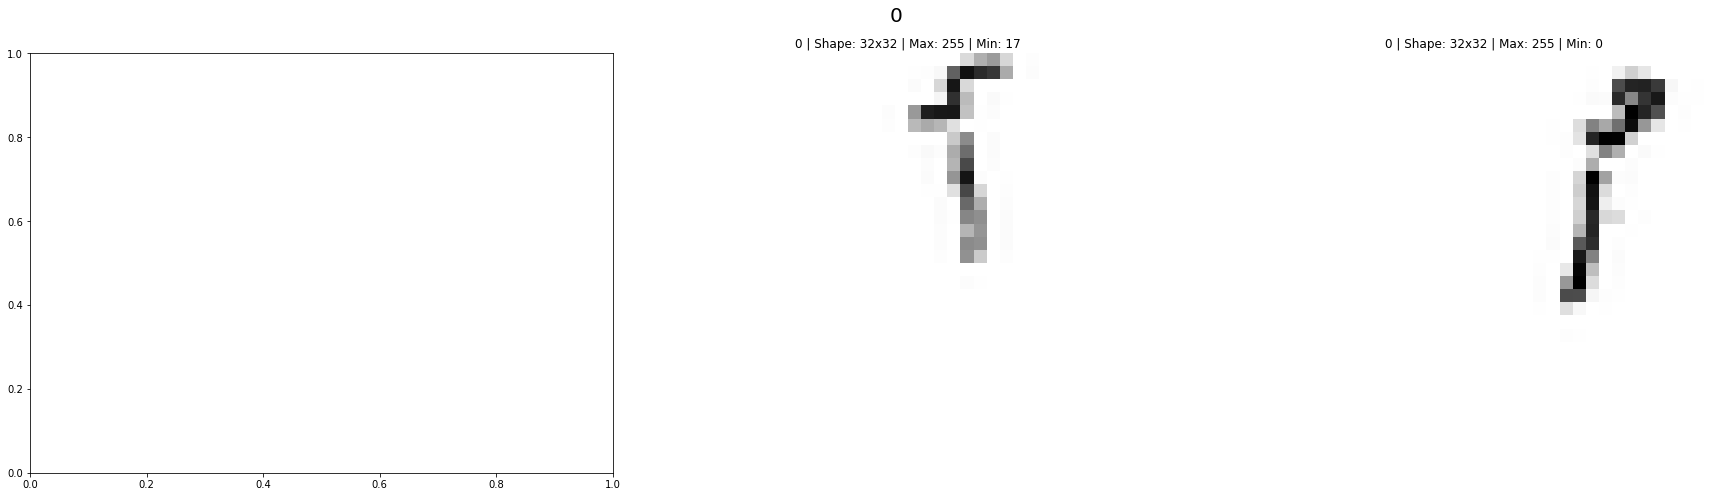

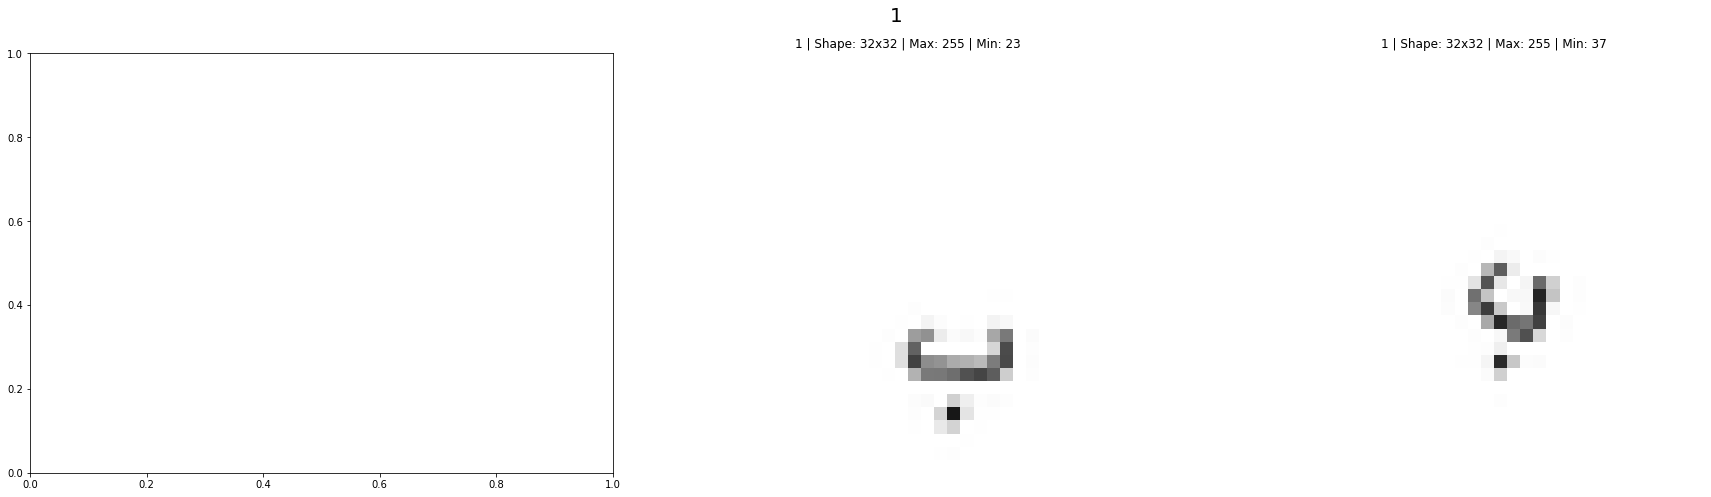

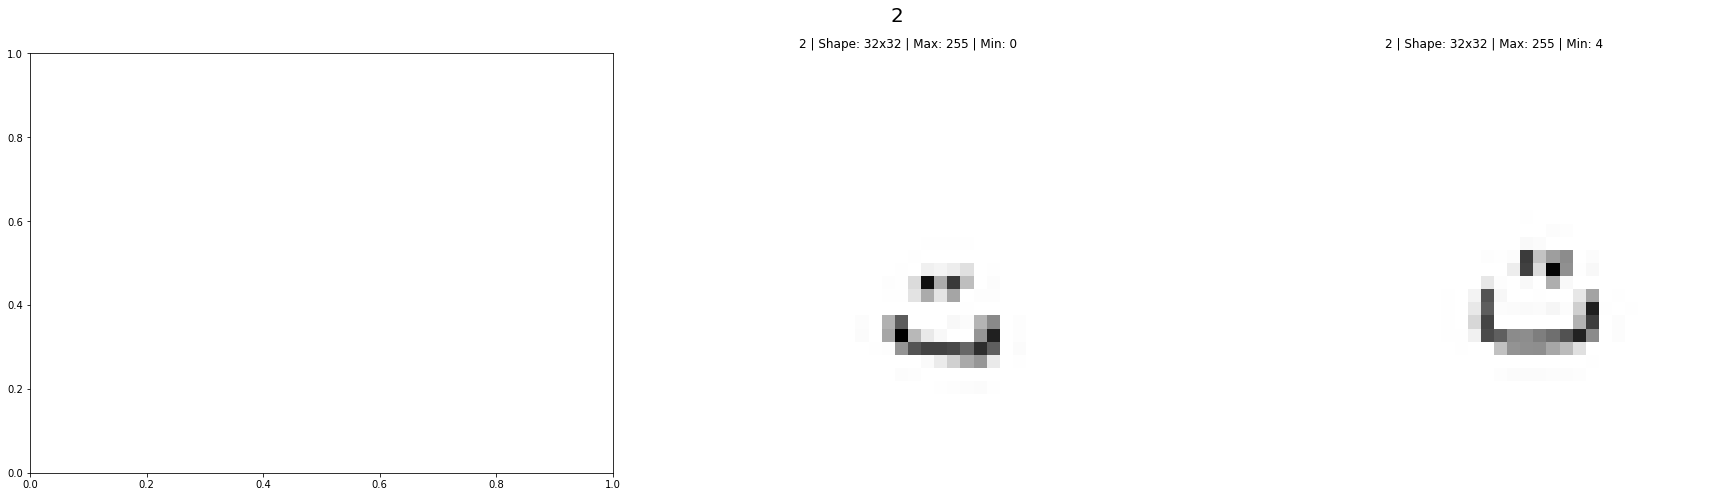

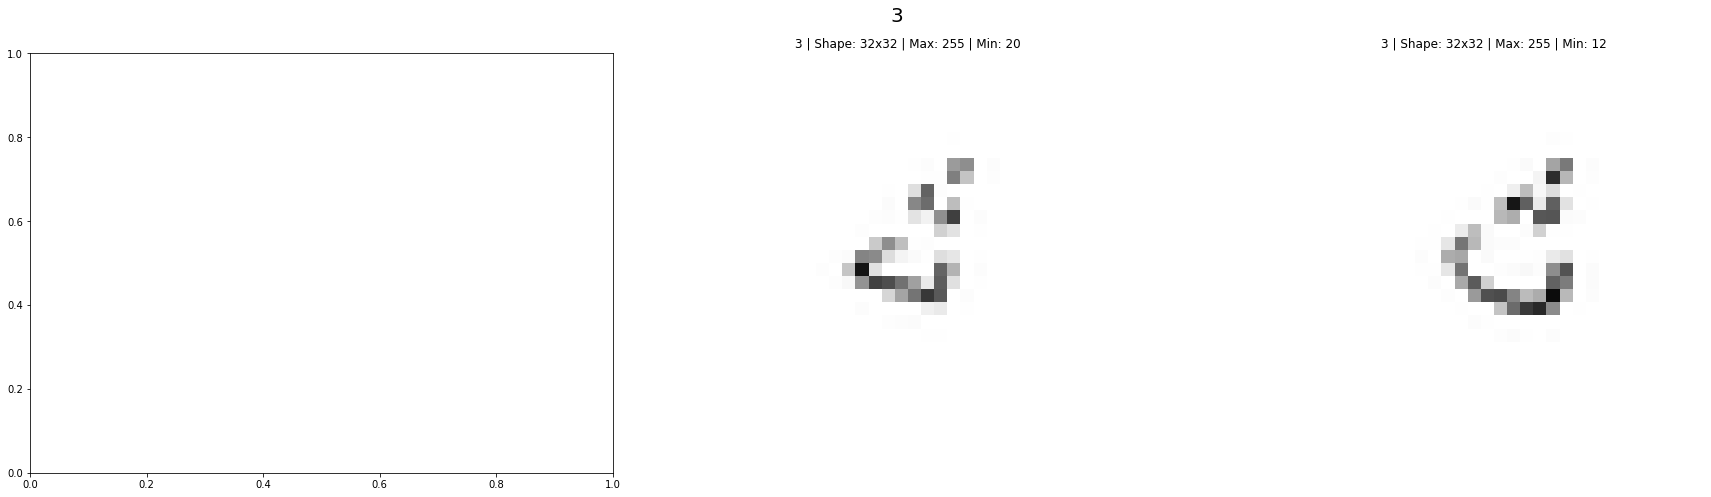

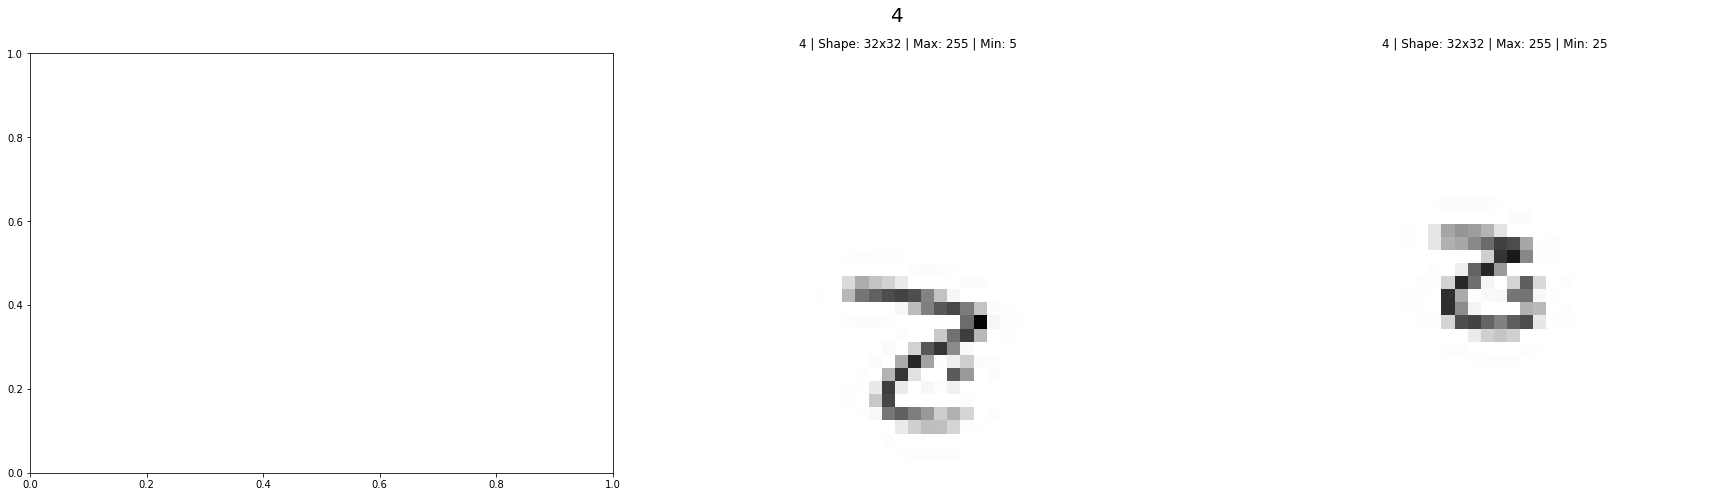

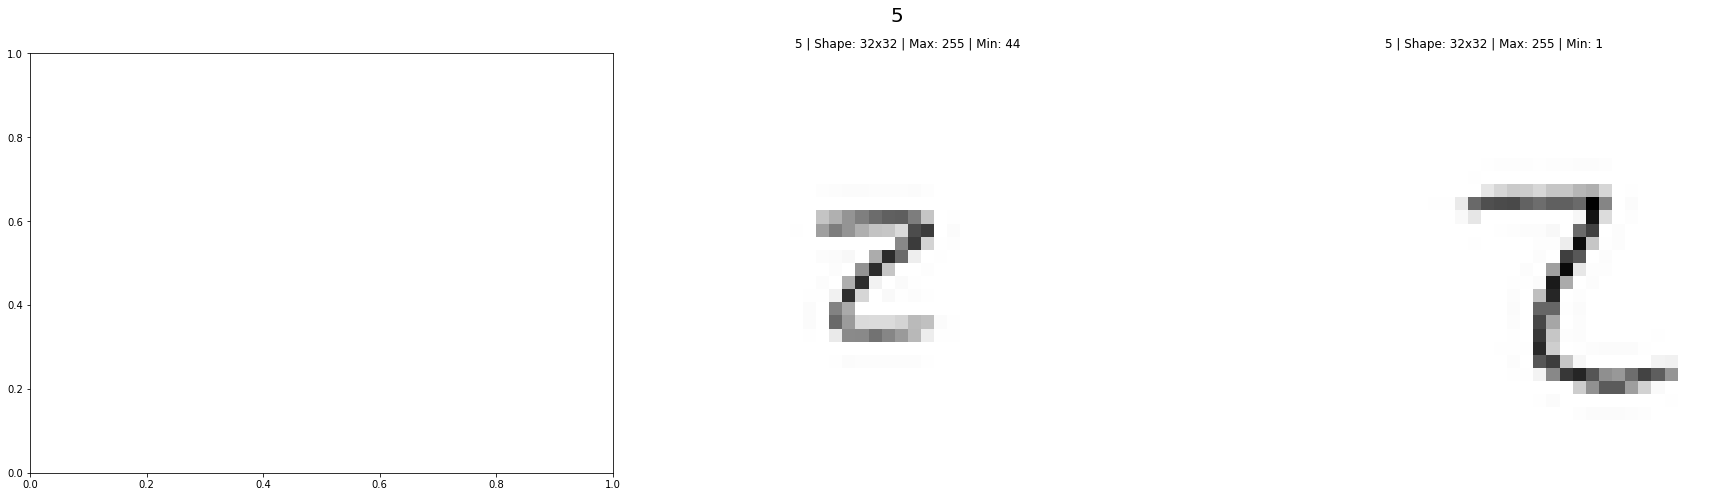

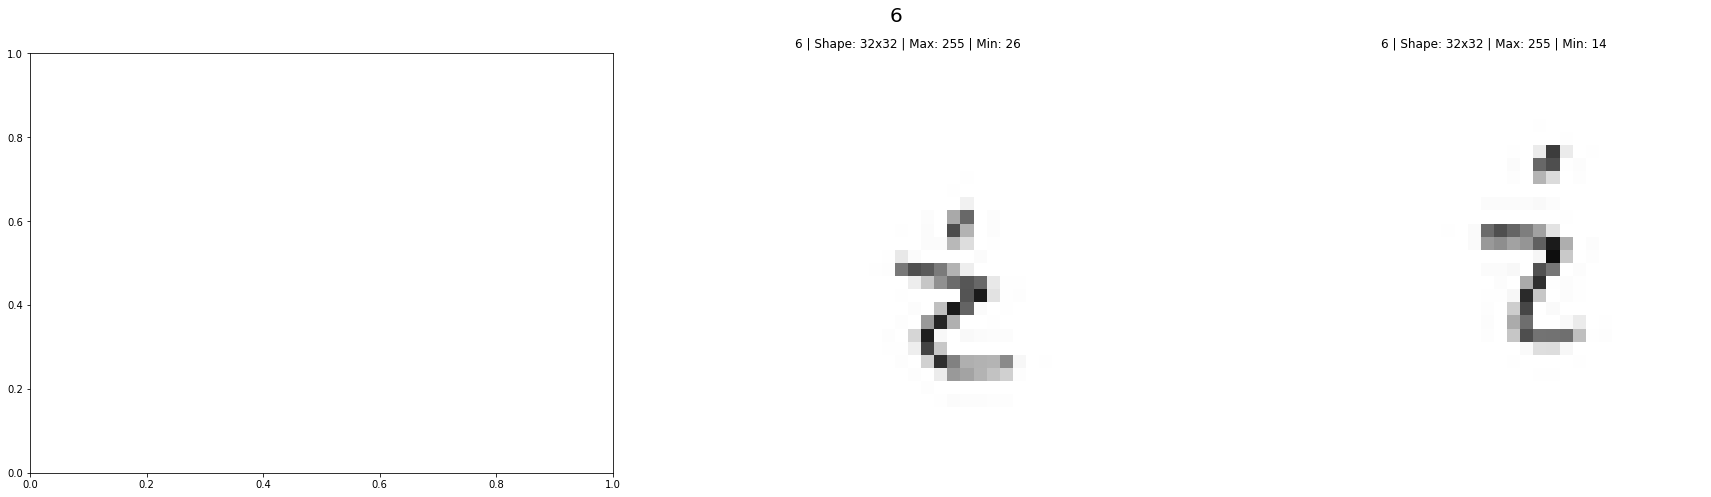

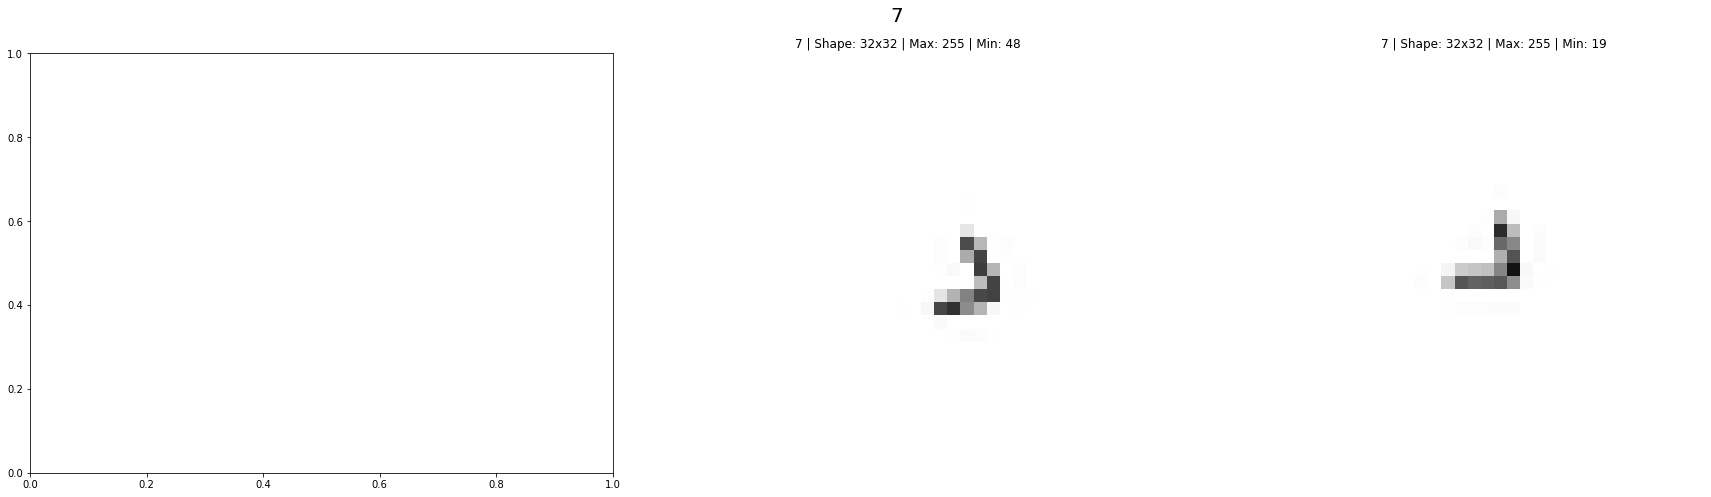

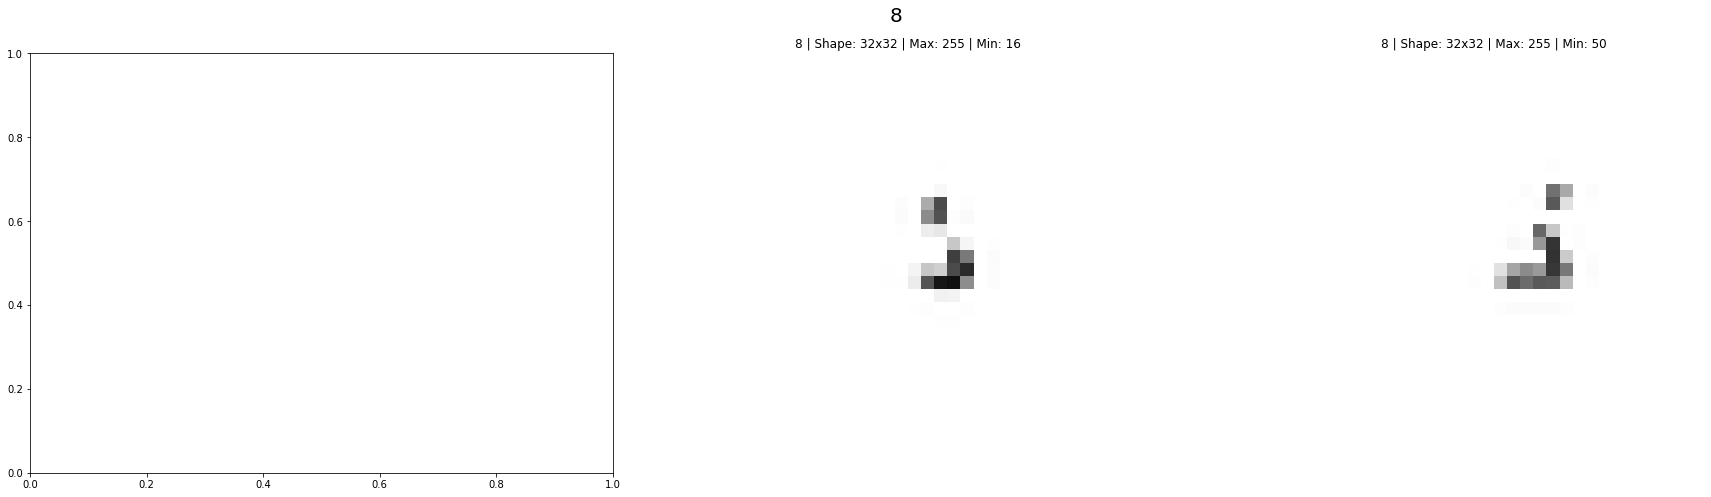

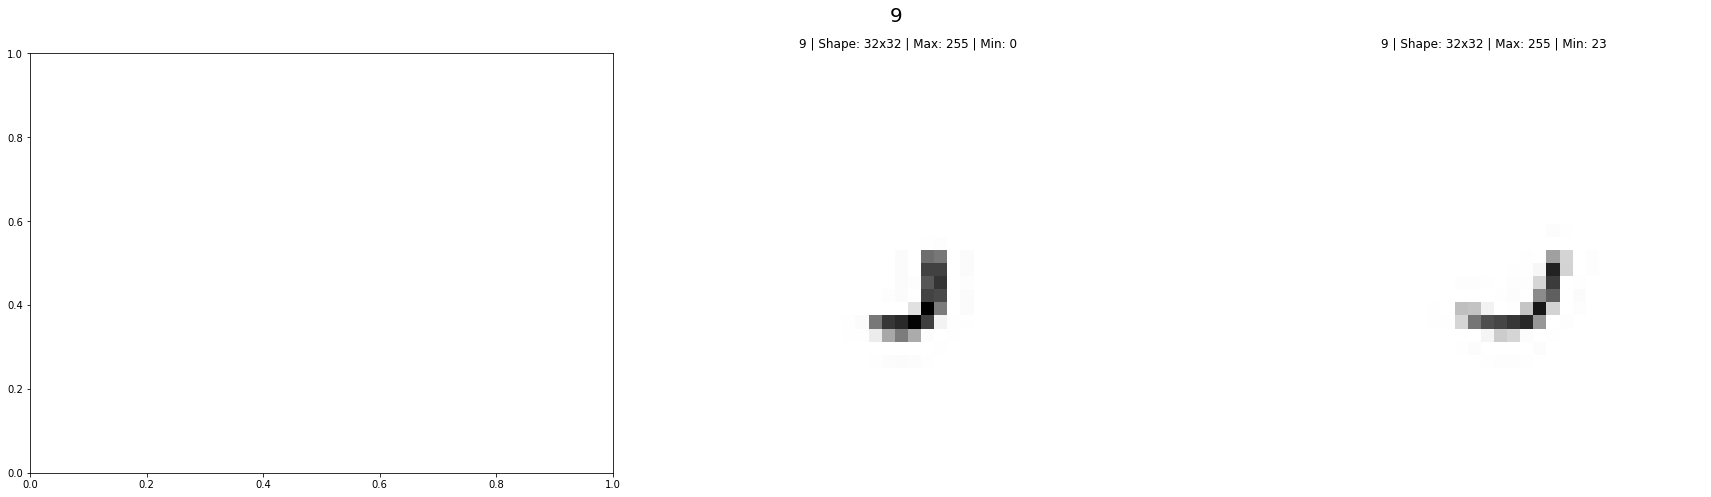

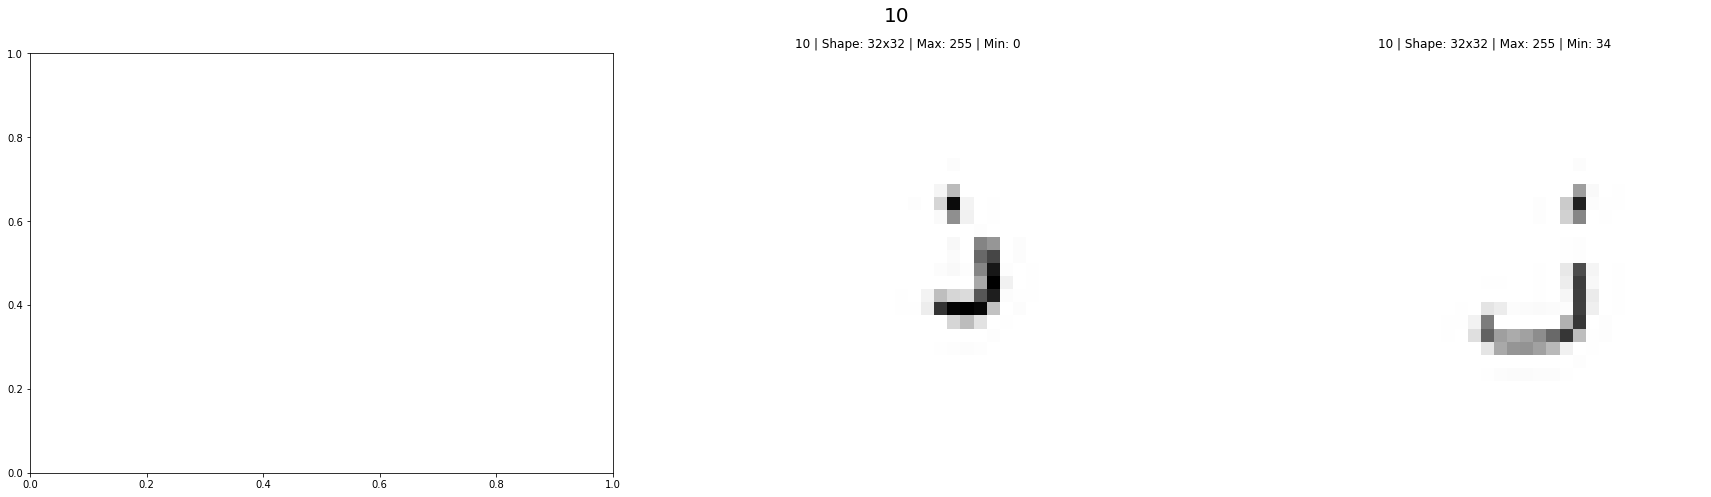

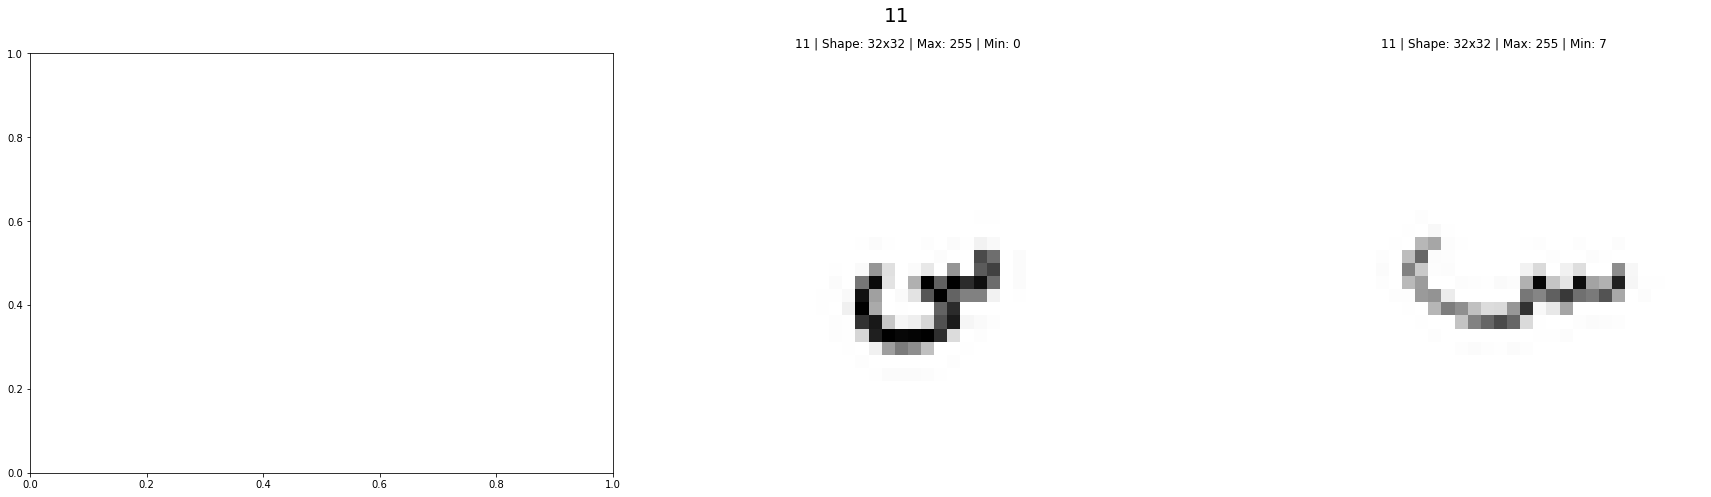

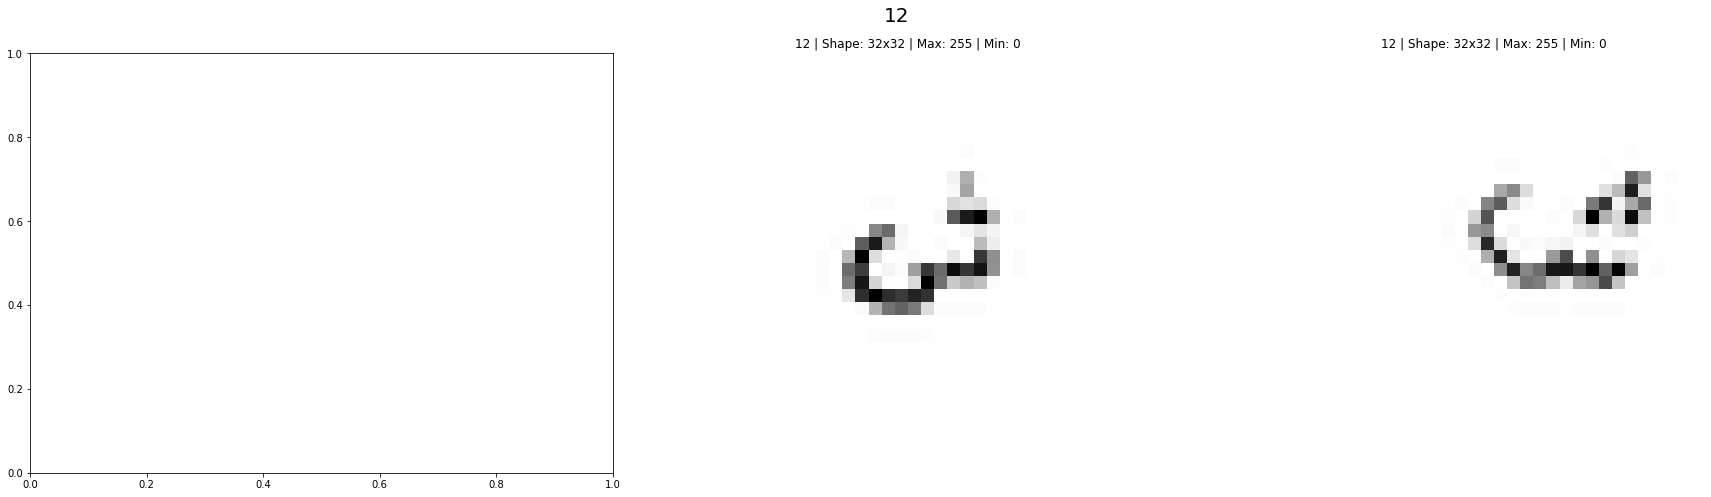

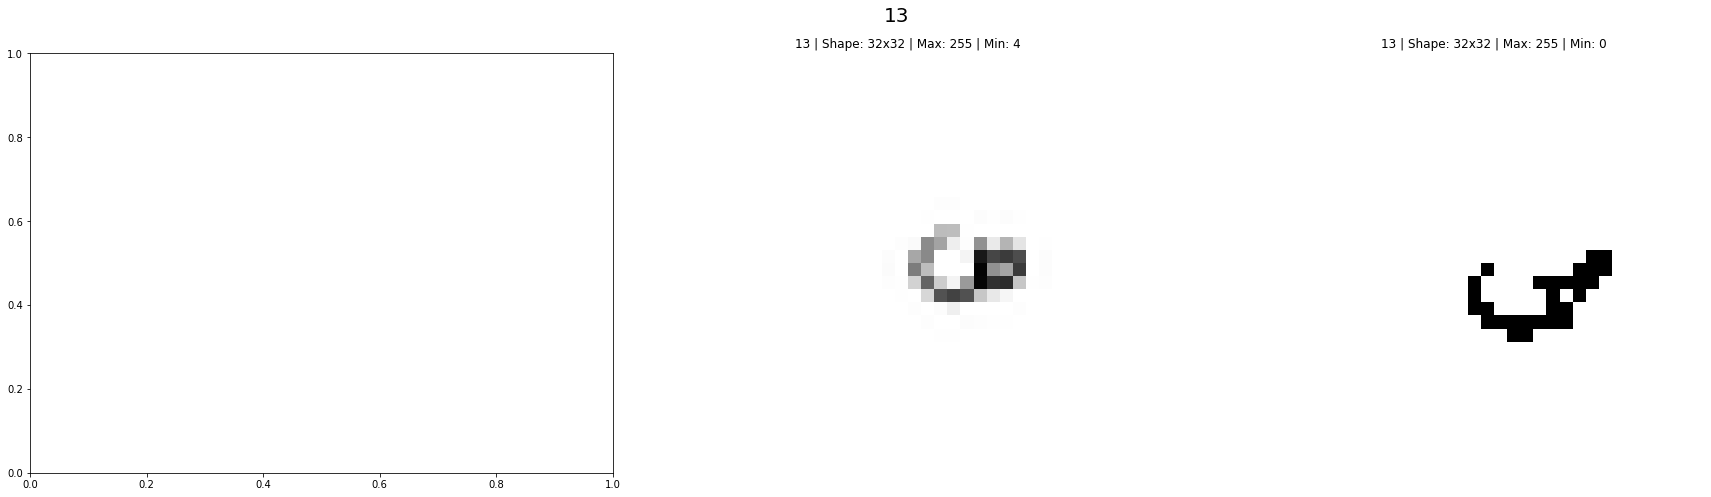

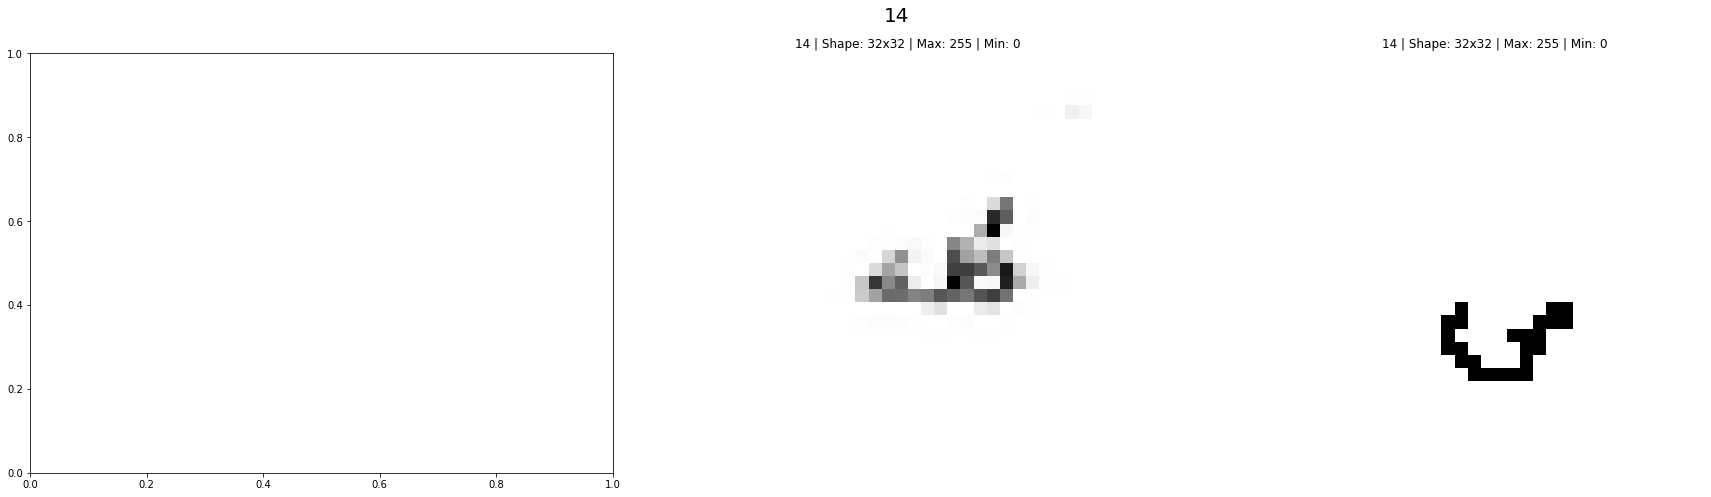

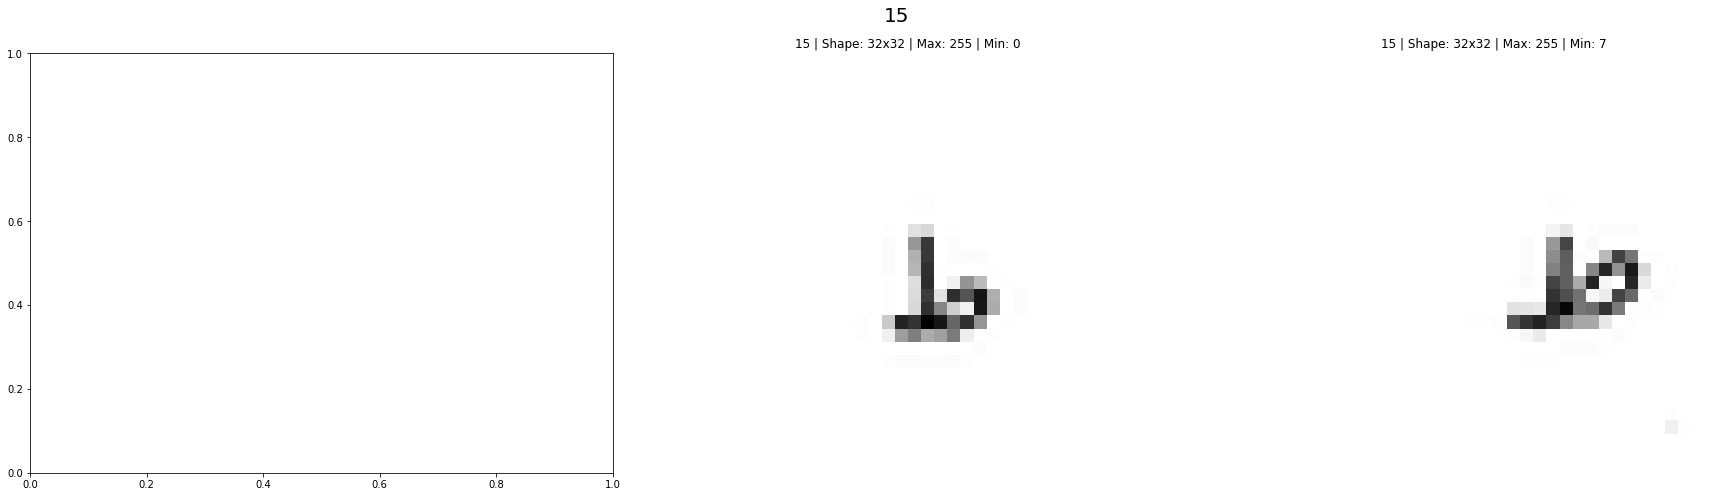

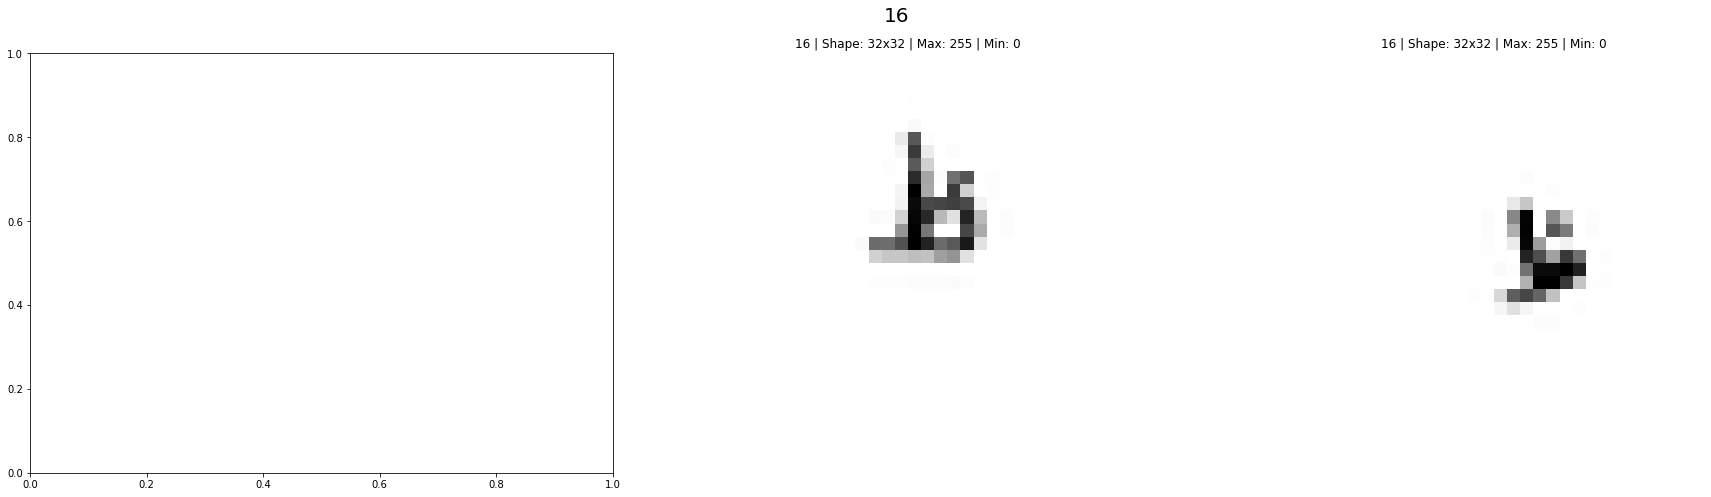

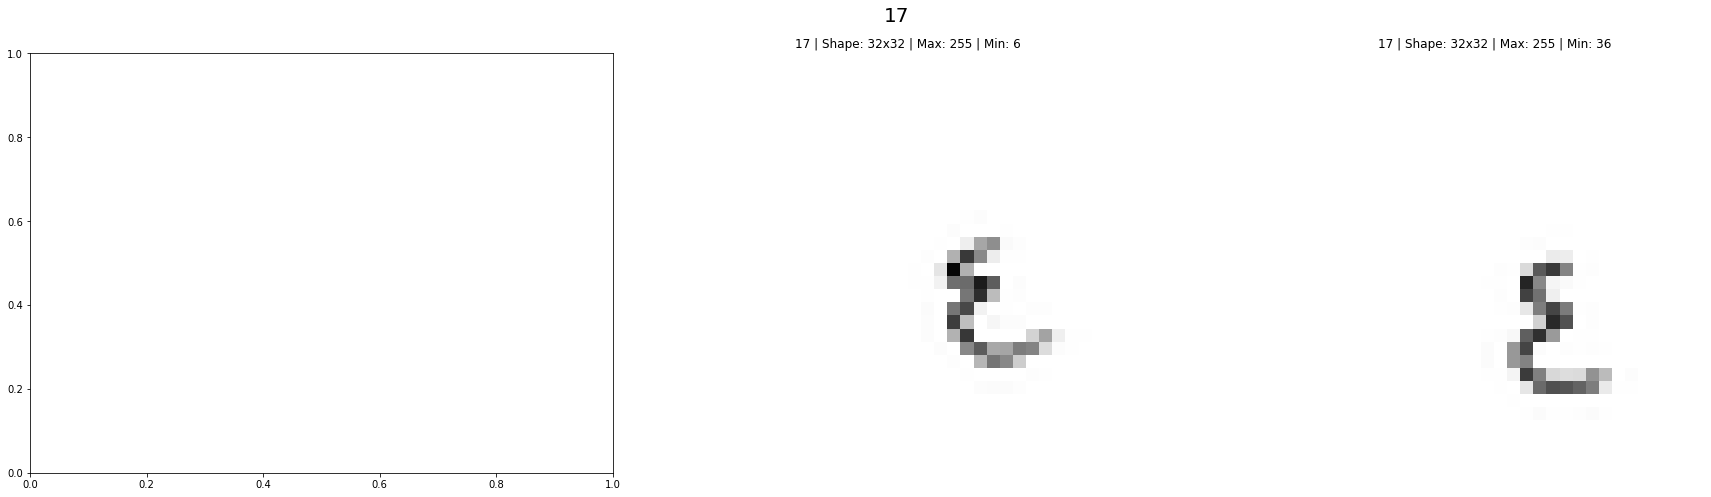

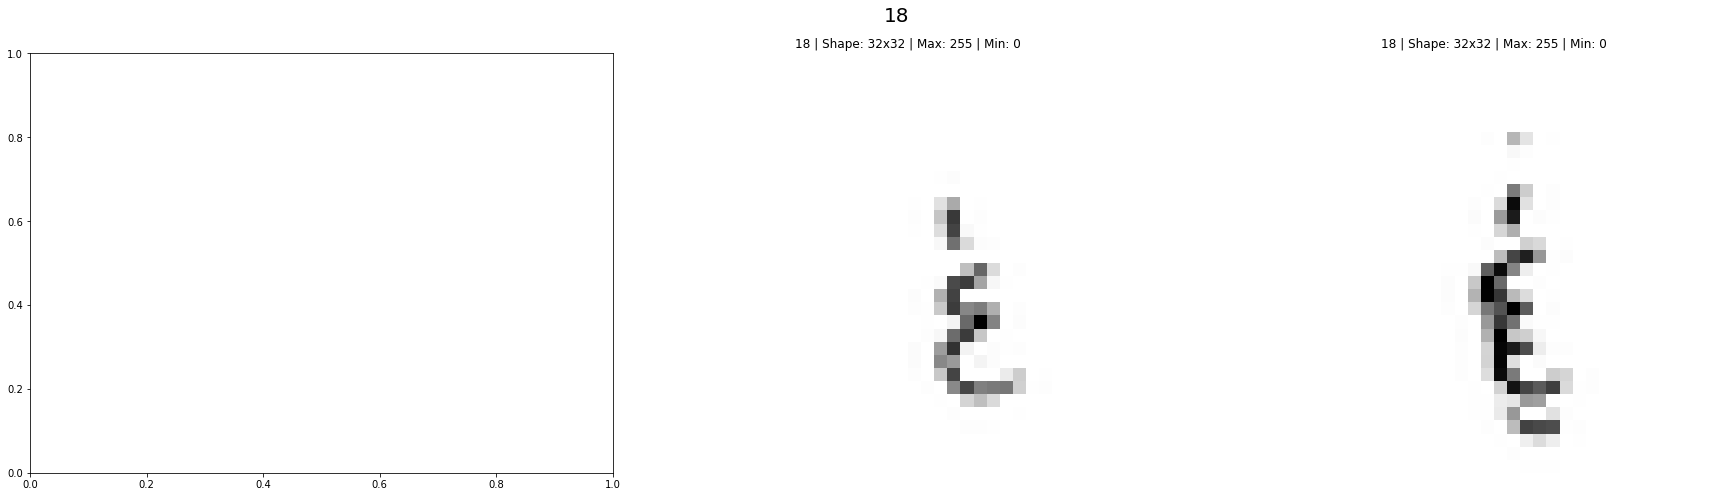

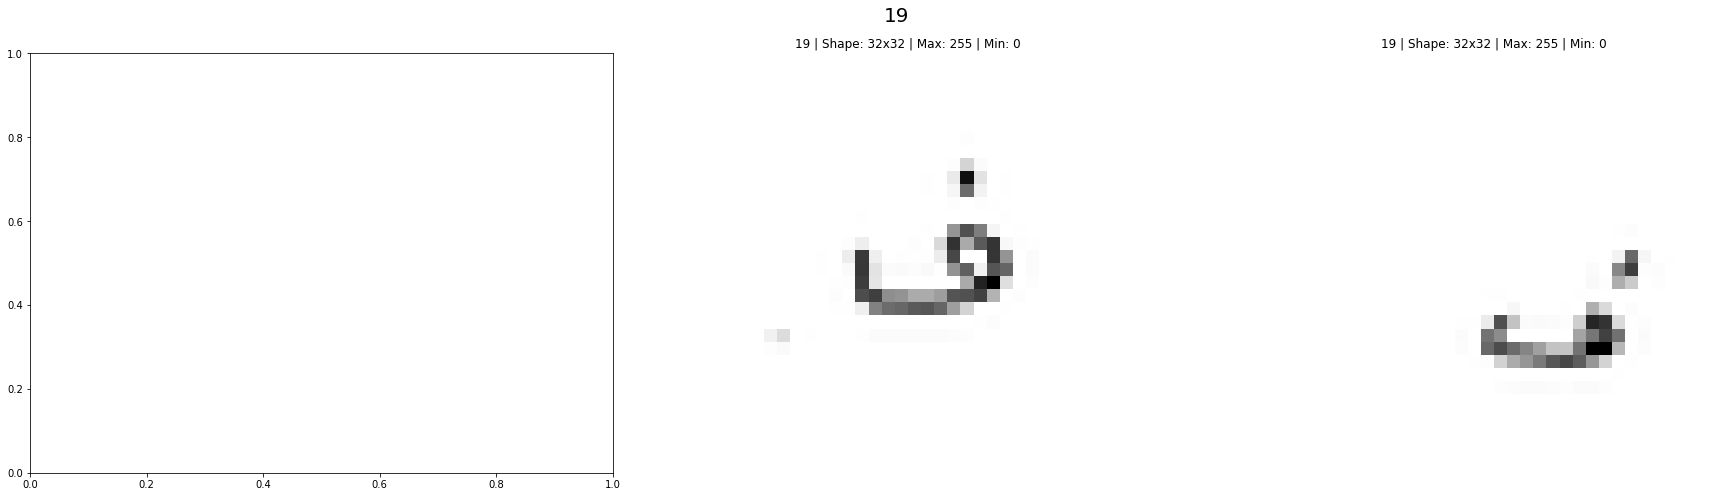

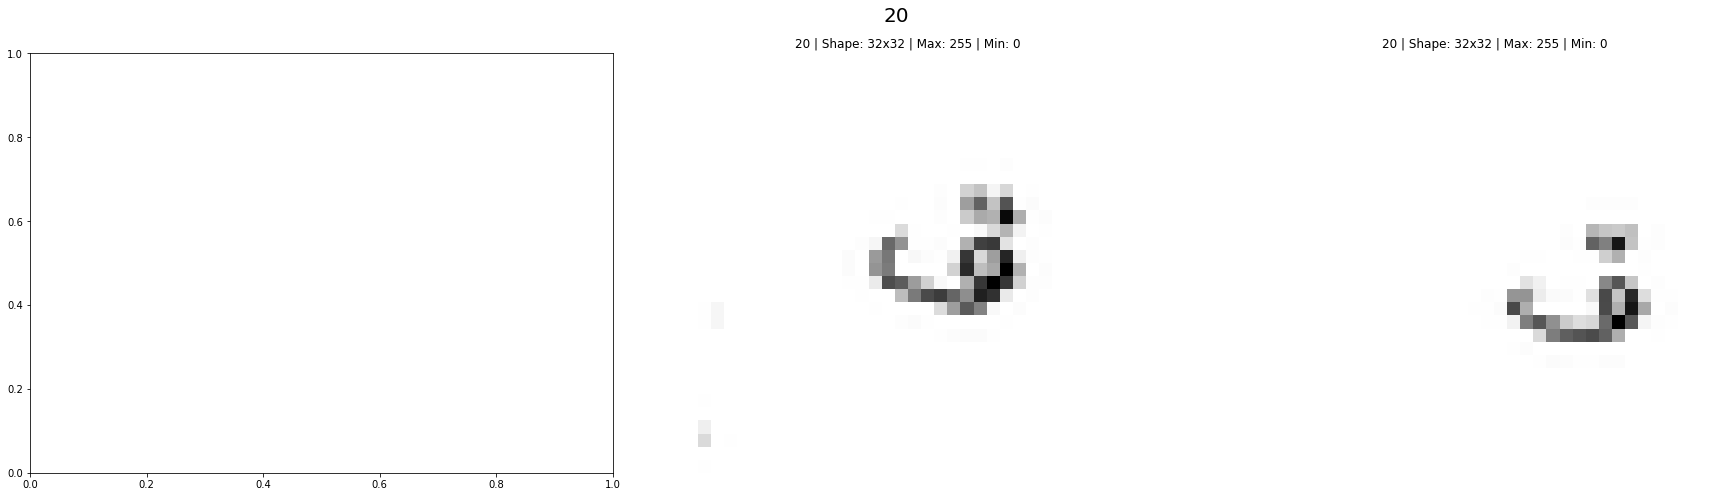

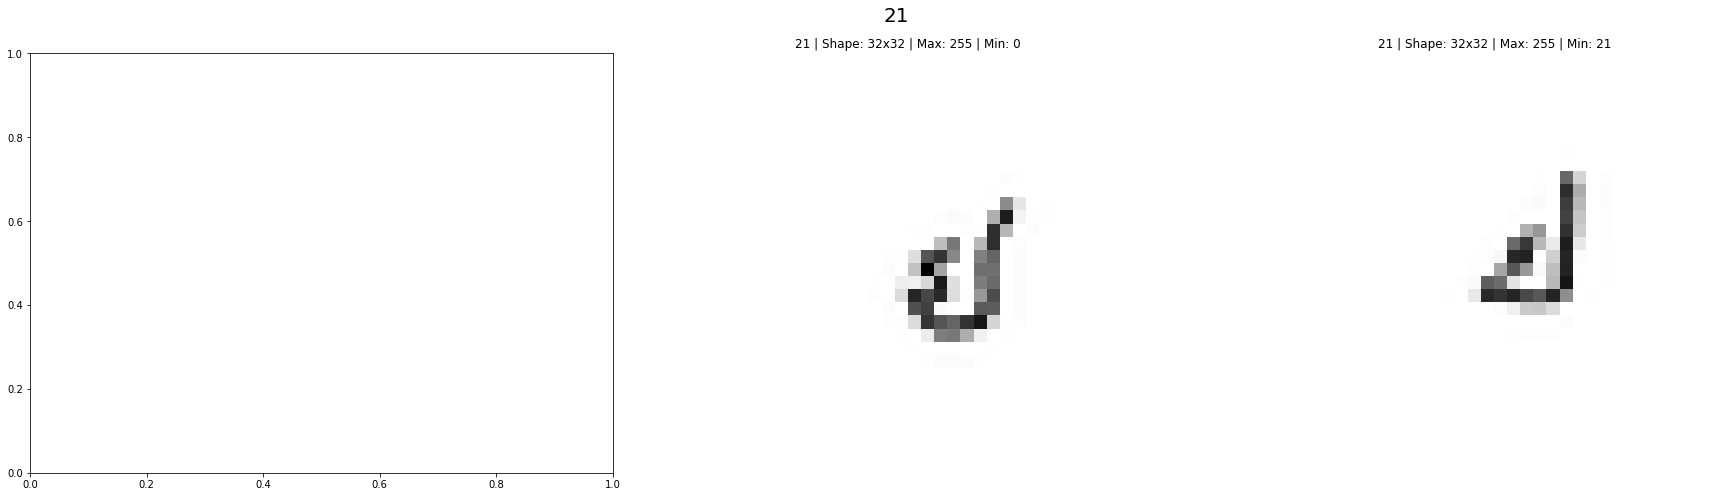

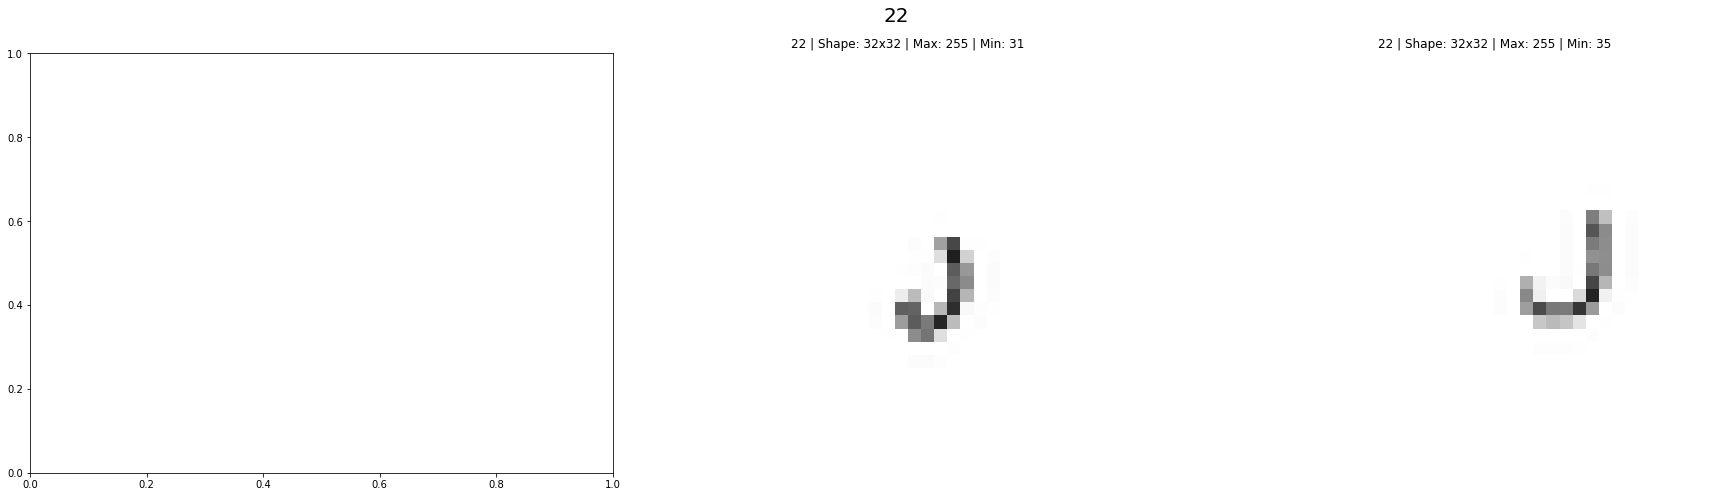

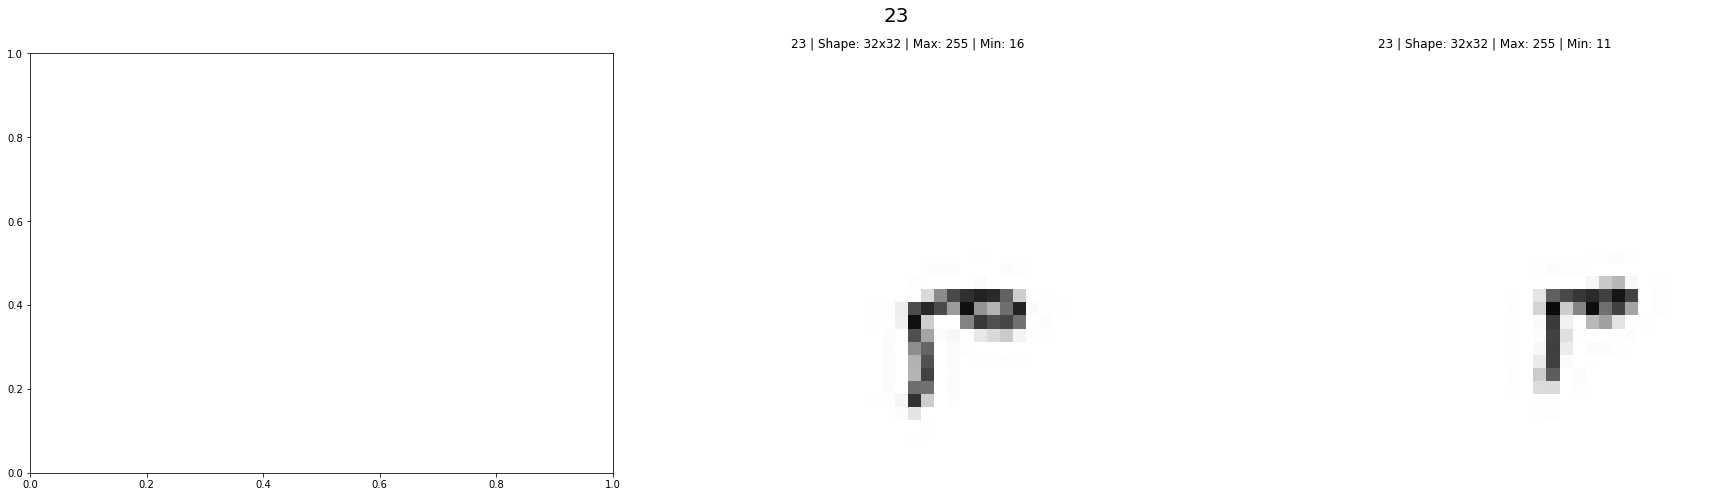

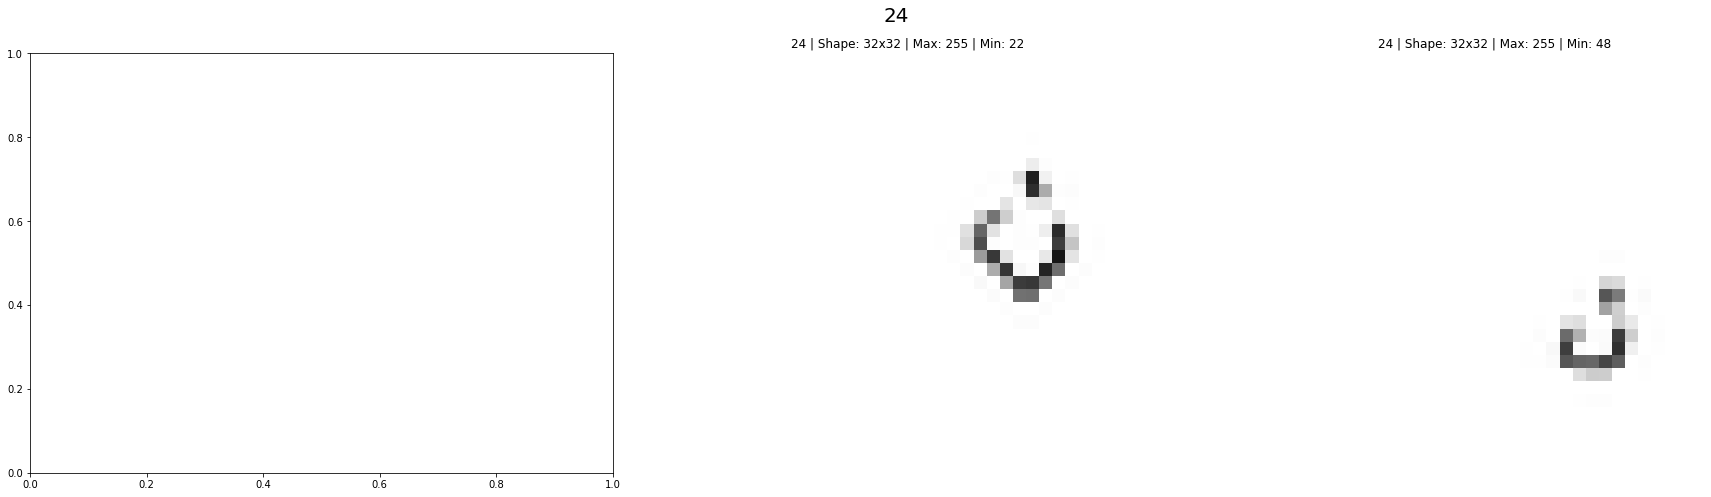

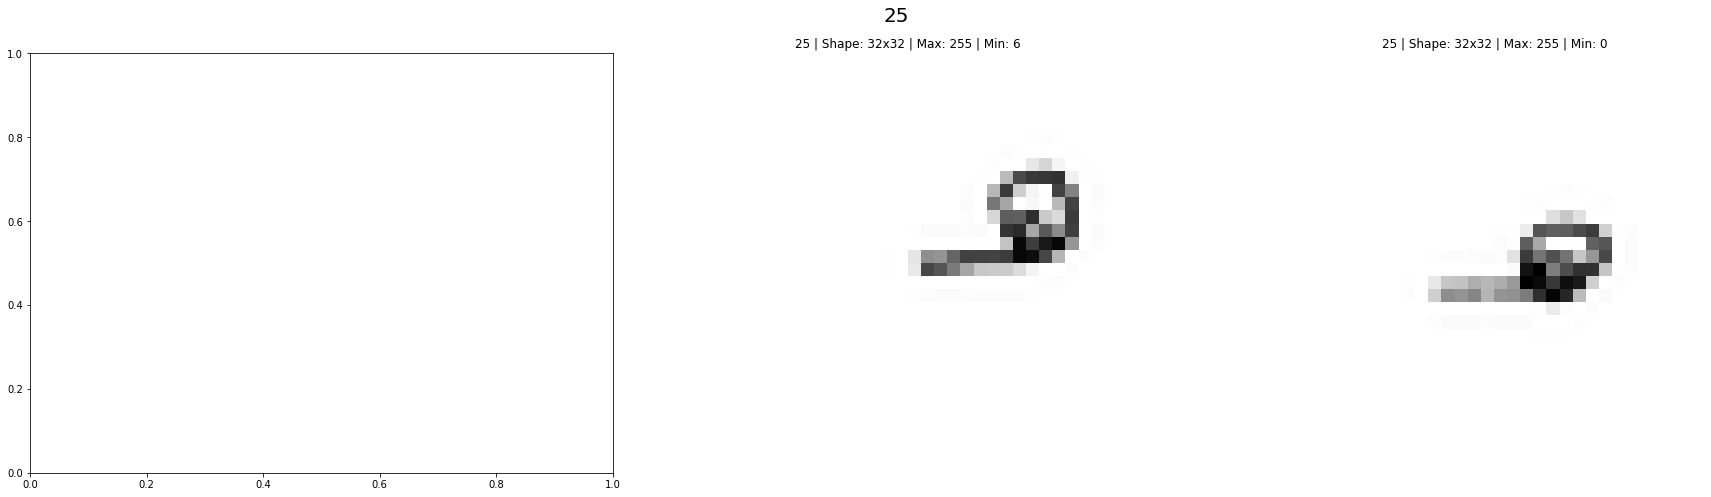

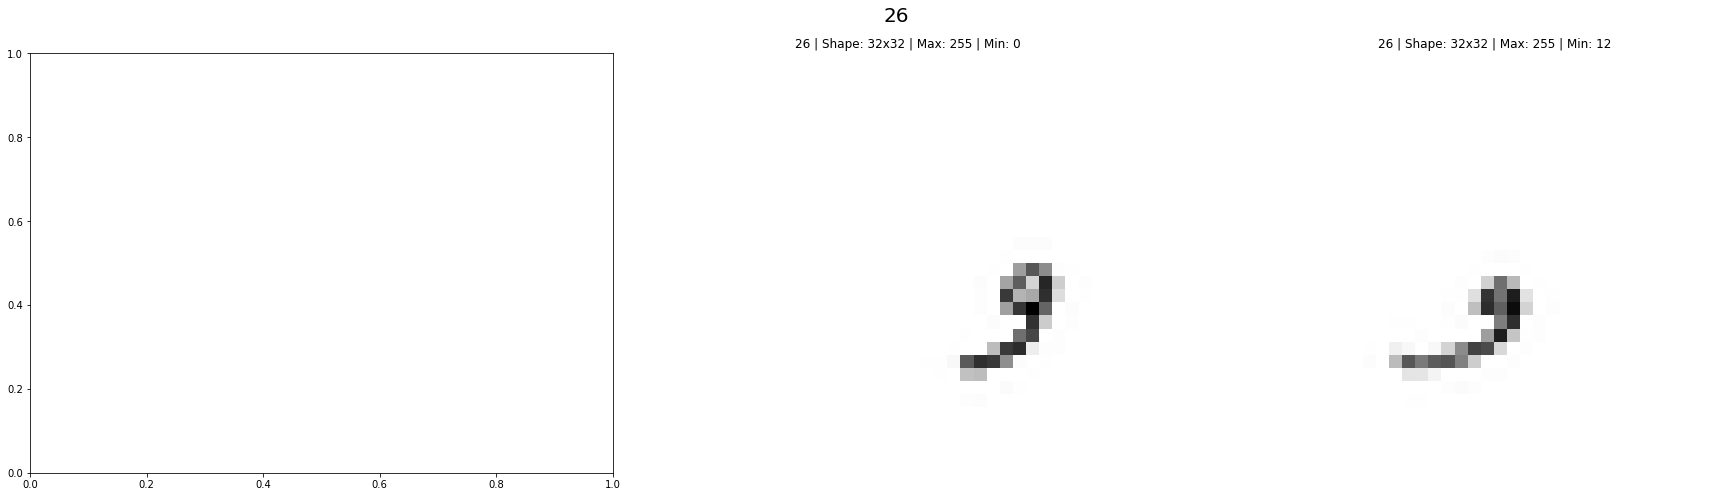

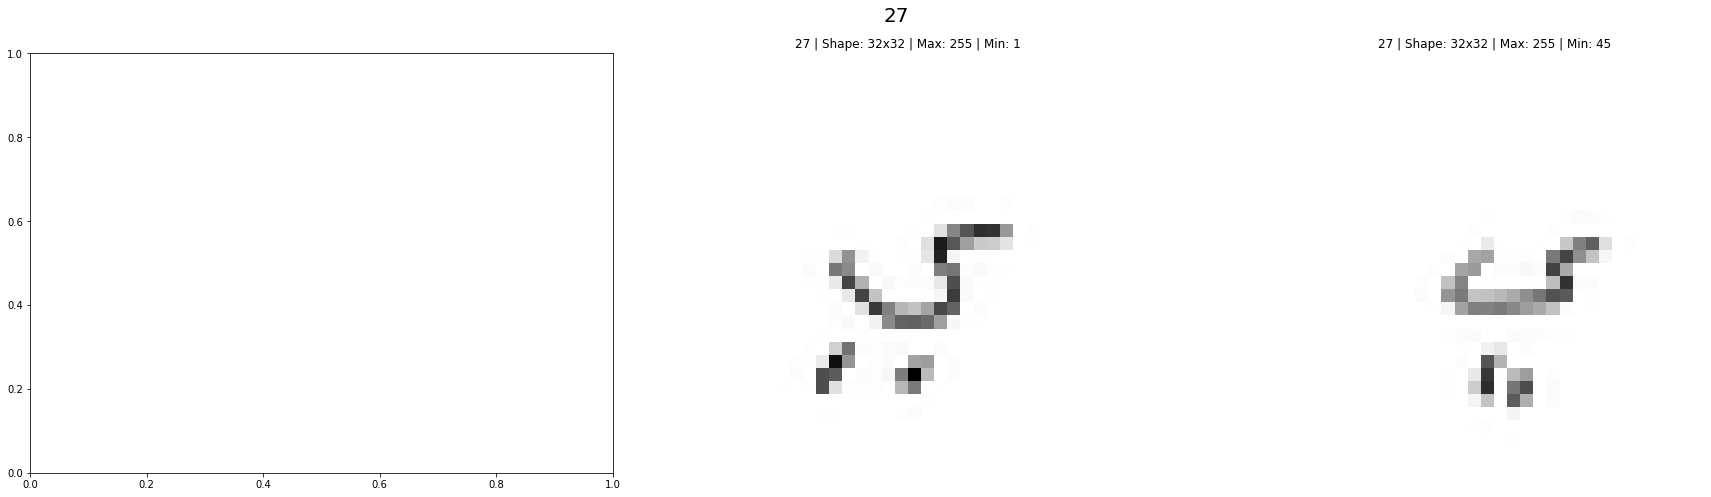

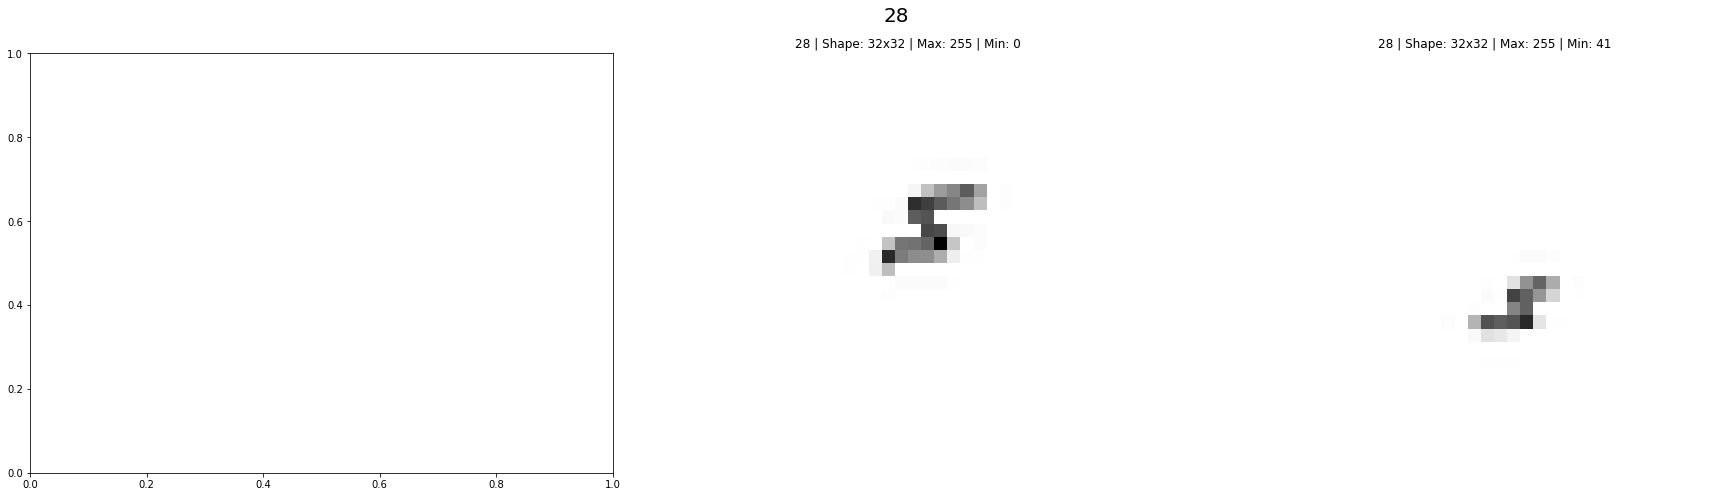

In [5]:

folder_original_data = 'Hijja Edited/Hijja Edited/'
files_original_data = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
                       '11', '12', '13', '14', '15', '16', '17', '18',
                       '19', '20', '21', '22', '23', '24', '25', '26',
                       '27', '28']

for file in files_original_data:
    path = os.path.join(folder_original_data, file)
    fig, axes = plt.subplots(1, 3, figsize=(25, 7))

    for i, img in enumerate(os.listdir(path)[:3]):
        if 'png' not in img:
            continue
        img_array = cv2.imread(os.path.join(path, img))
        img_array_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Get image shape and pixel values
        img_shape = img_array.shape
        max_pixel = np.max(img_array)
        min_pixel = np.min(img_array)

        # Set the title with image shape, max, and min pixel values
        axes[i].imshow(img_array_rgb)
        axes[i].set_title(f"{file} | Shape: {img_shape[0]}x{img_shape[1]} | Max: {max_pixel} | Min: {min_pixel}")
        axes[i].axis('off')

    plt.suptitle(f'{file}', fontsize=20)
    plt.tight_layout()
    plt.show()

In [6]:
data_transforms = transforms.Compose([
    transforms.Resize((32, 32), interpolation=Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize([0.485], [0.229])  # Normalization
])

data_dir1 = 'Hijja Edited/Hijja Edited'

image_dataset = datasets.ImageFolder(data_dir1, transform=data_transforms)

# class_counts_before = {class_name: 0 for class_name in image_dataset.classes}
# for _, label in image_dataset:
#     class_counts_before[image_dataset.classes[label]] += 1

# for class_name, count in class_counts_before.items():
#     print(f"{class_name}: {count}")
# print(f"Total number of images : {len(image_dataset)}\n")

#class_indices = {class_name: [] for class_name in image_dataset.classes}
#for idx, (_, label) in enumerate(image_dataset):
    #class_name = image_dataset.classes[label]
    #class_indices[class_name].append(idx)

#target_count = 500

#upsampled_datasets = []

#for class_name, indices in class_indices.items():
    #current_count = len(indices)
    #if current_count < target_count:
        # Number of extra images needed
        #additional_count = target_count - current_count

        # Randomly sample with replacement from current indices
        #additional_indices = np.random.choice(indices, additional_count, replace=True)

        # Combine original and additional indices
        #combined_indices = indices + additional_indices.tolist()

        # Create Subset for the upsampled class
        #upsampled_dataset = Subset(image_dataset, combined_indices)
    #else:
        # Use existing data if it already meets or exceeds target count
        #upsampled_dataset = Subset(image_dataset, indices)

    #upsampled_datasets.append(upsampled_dataset) ""

final_dataset1 = image_dataset

dataloader = DataLoader(final_dataset1, batch_size=32, shuffle=True)

# print("Class distribution after BALANCNG:")
# new_class_counts = {class_name: 0 for class_name in image_dataset.classes}
# for _, labels in dataloader:
#     for label in labels:
#         new_class_counts[image_dataset.classes[label.item()]] += 1

# for class_name, count in new_class_counts.items():
#     print(f"{class_name}: {count}")
# print(f"Total number of images after BALANCNG: {len(final_dataset)}")


C:\Users\MUHAMM~1\AppData\Local\Temp/ipykernel_17392/551442417.py:2: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  transforms.Resize((32, 32), interpolation=Image.BICUBIC),


In [7]:
for img , label in dataloader:
    print(img.shape)
    break

torch.Size([32, 3, 32, 32])


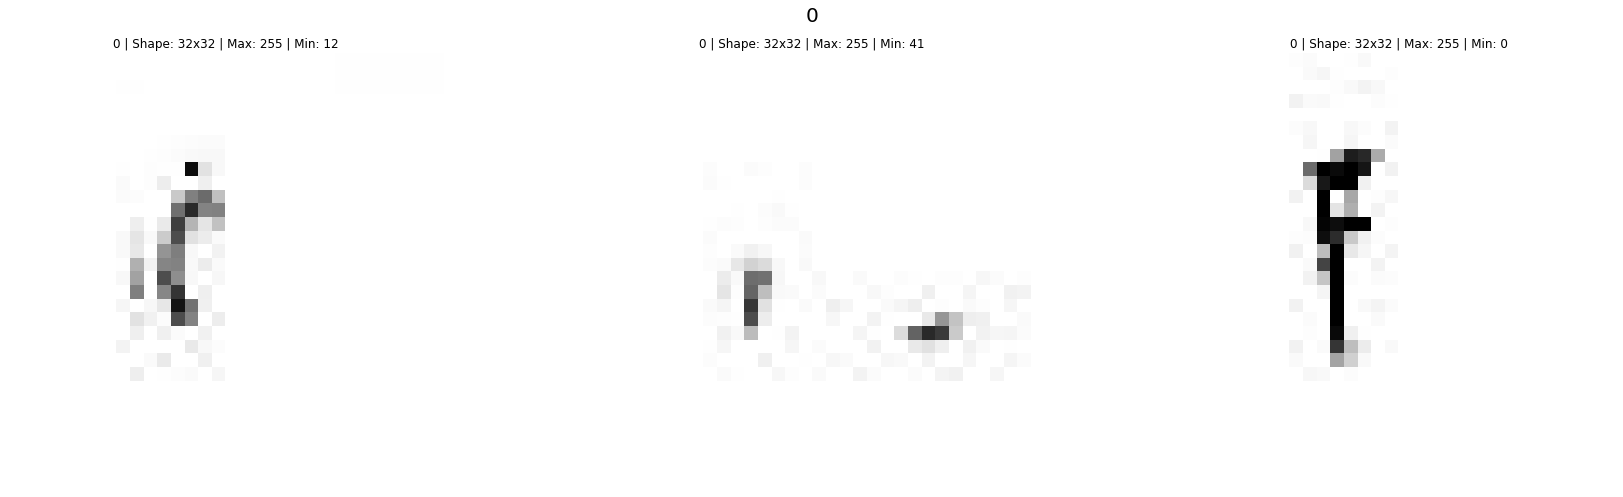

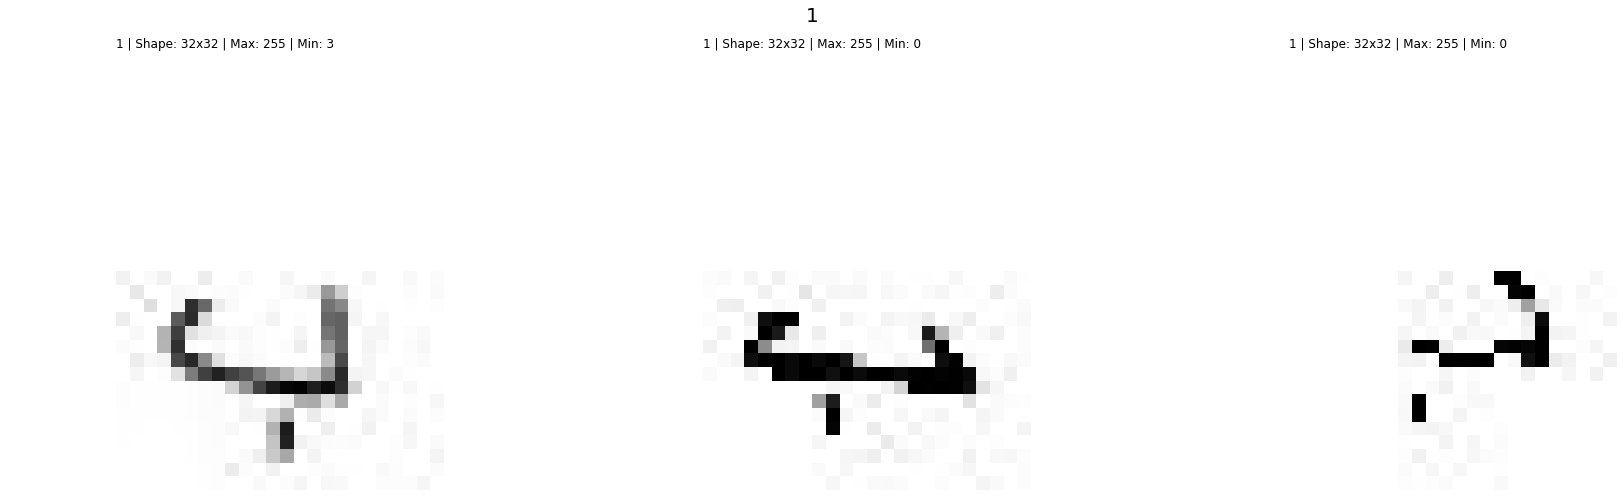

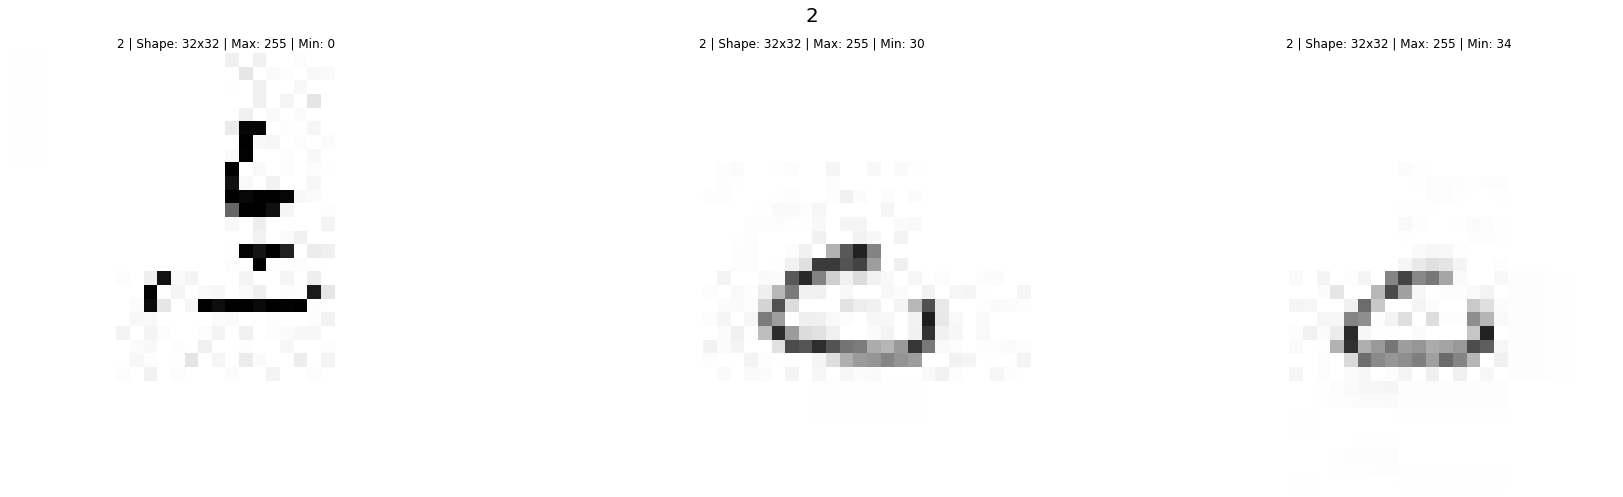

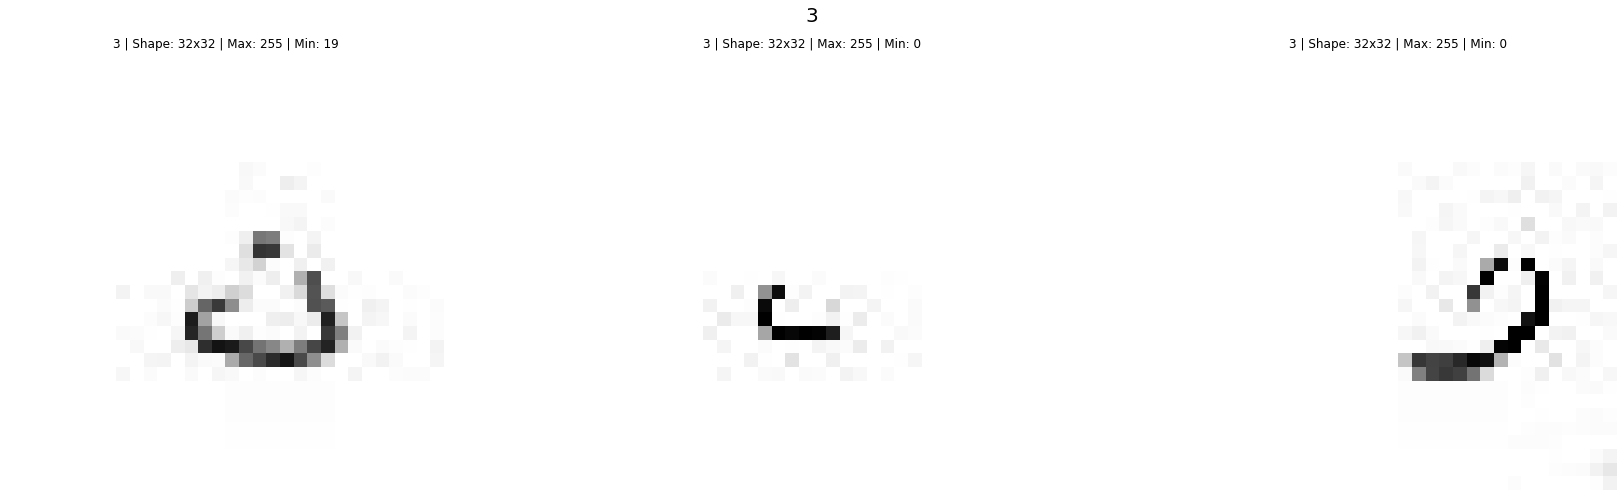

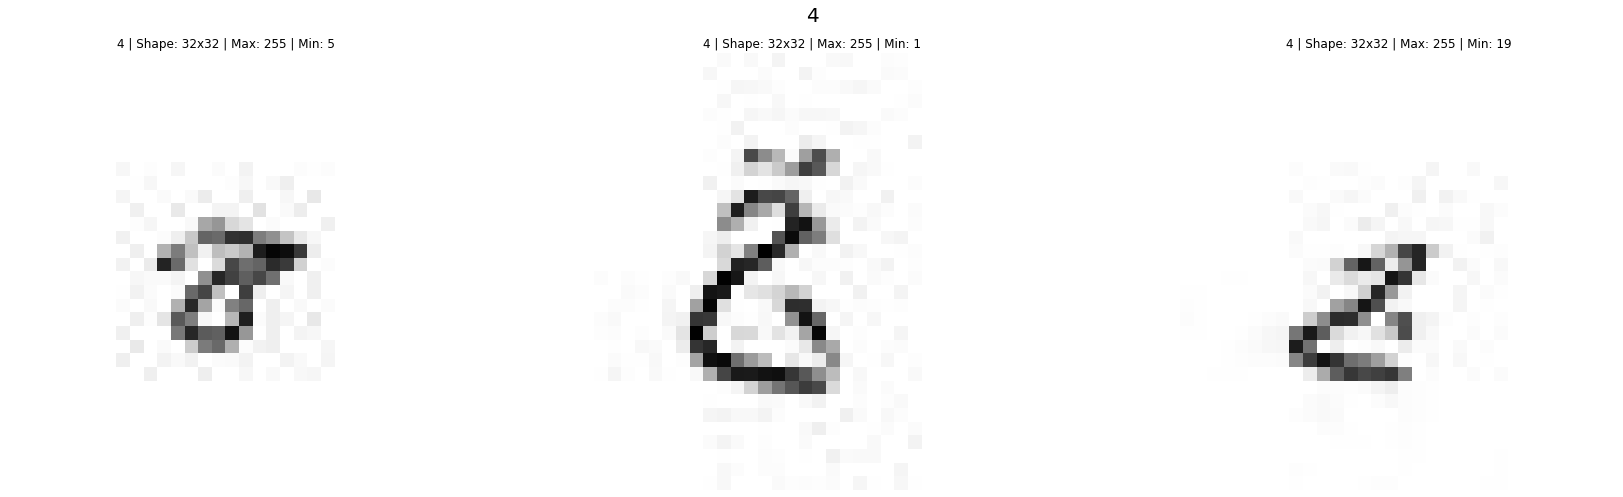

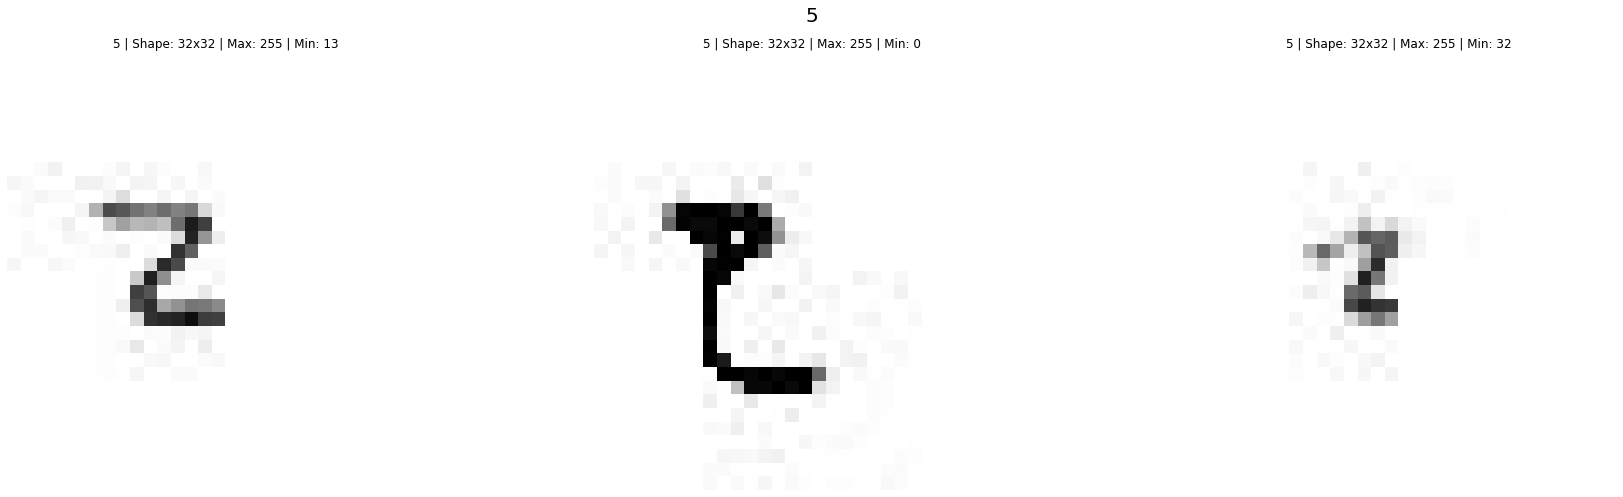

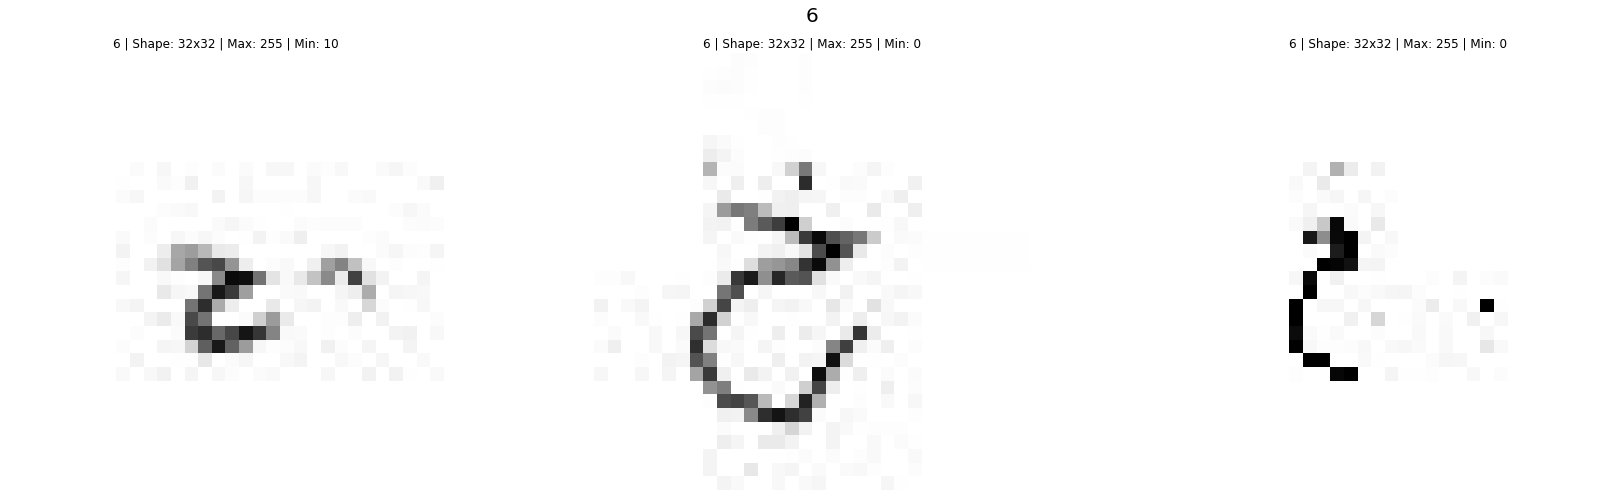

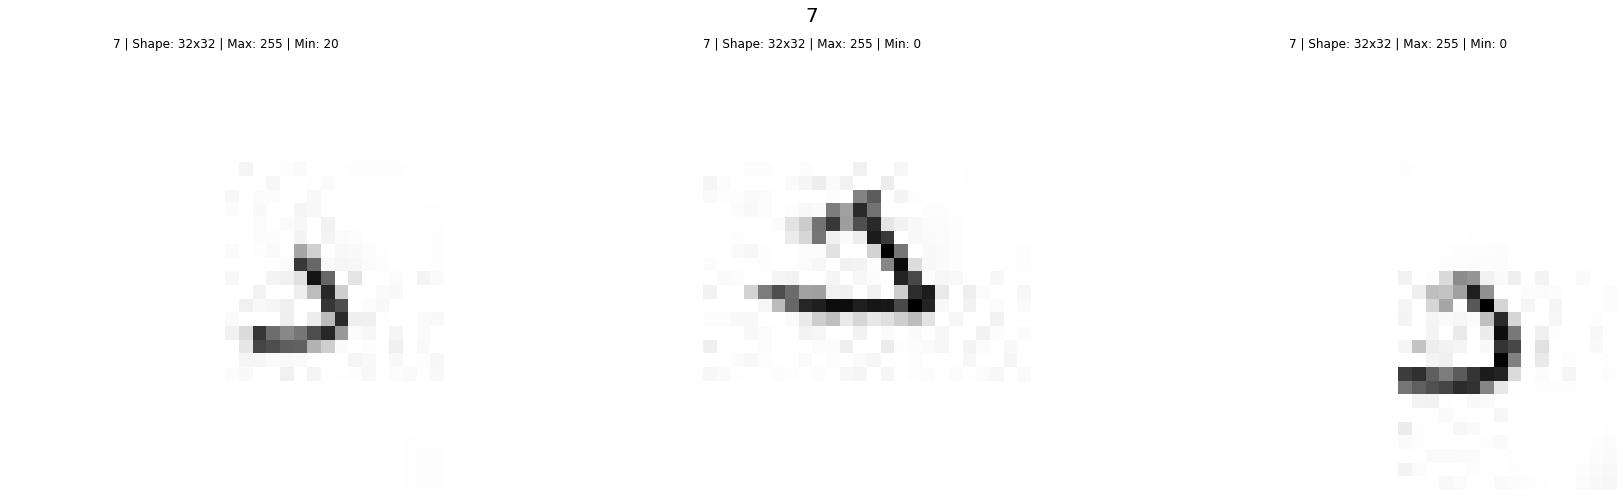

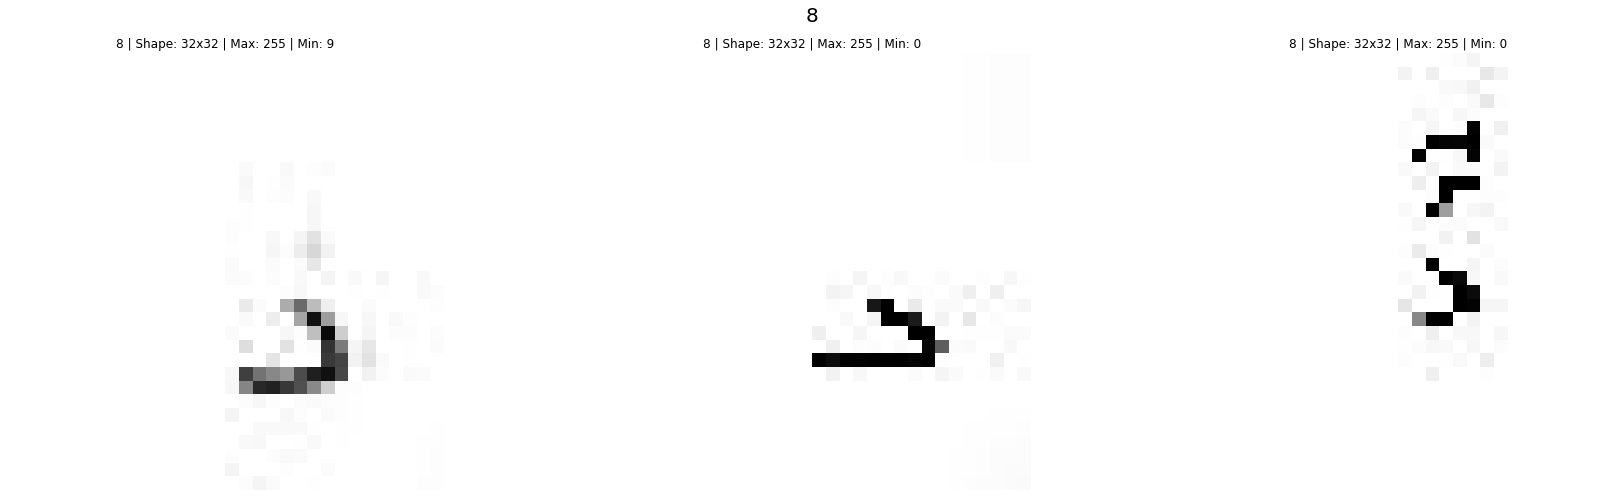

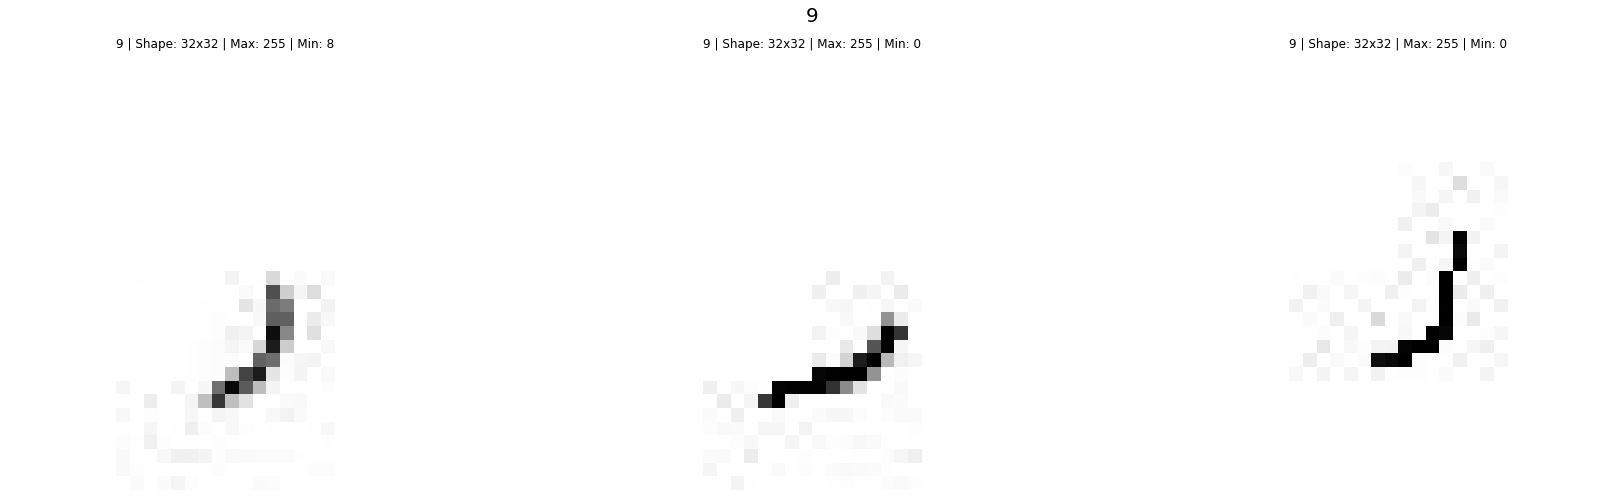

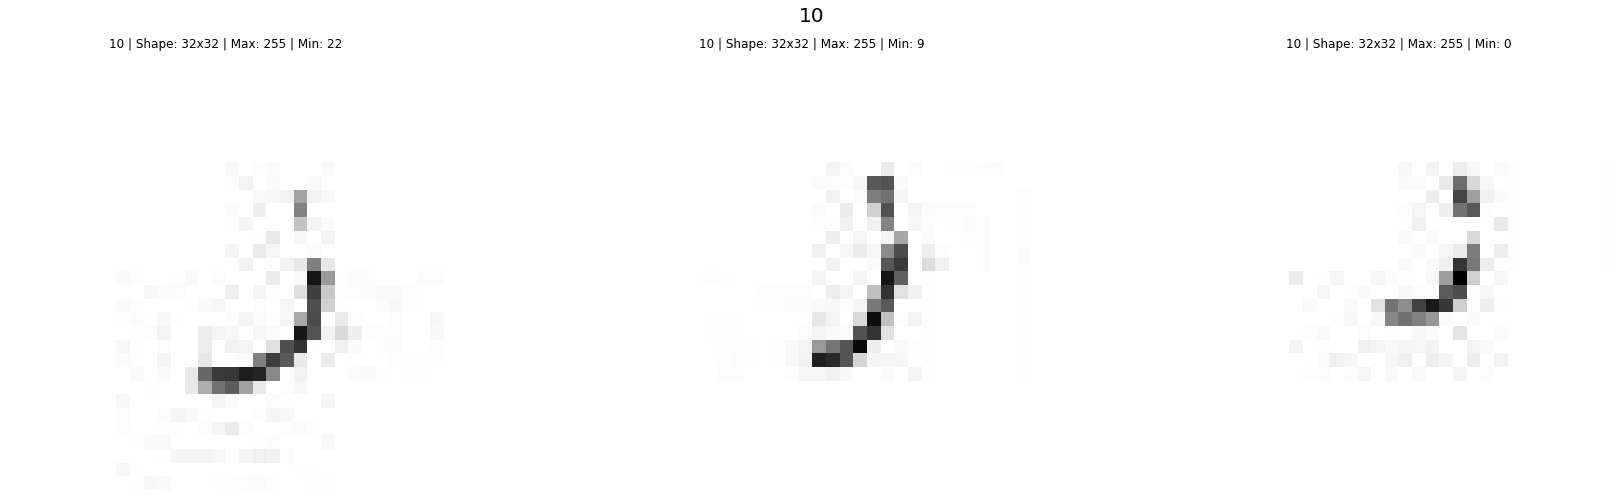

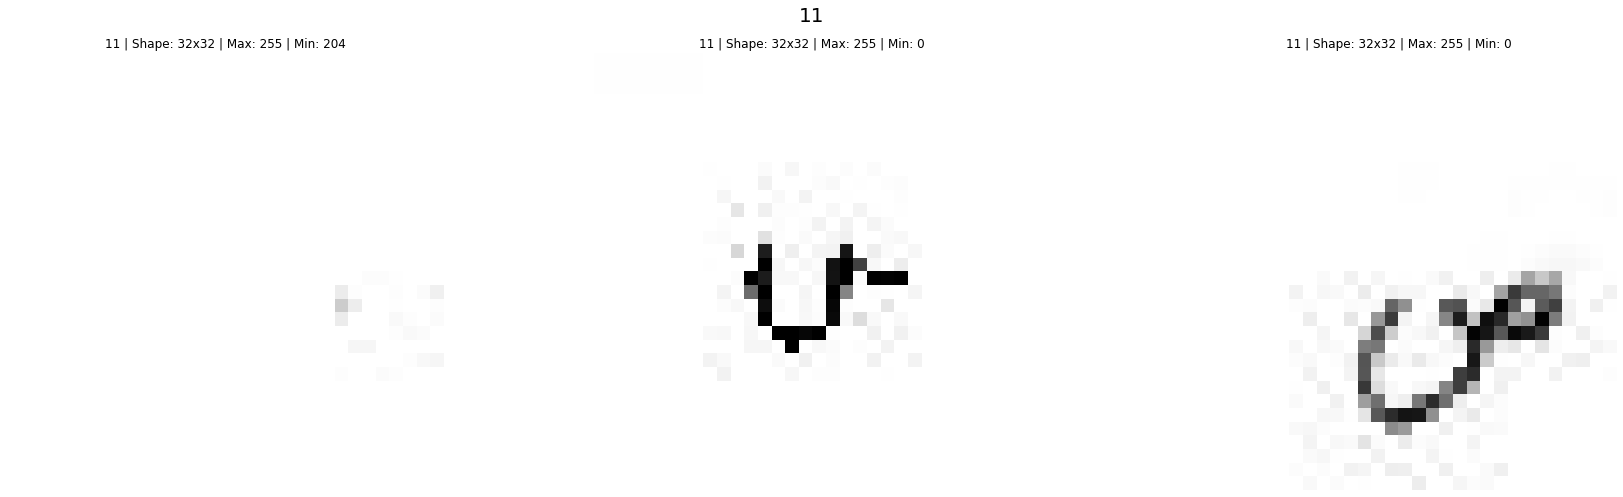

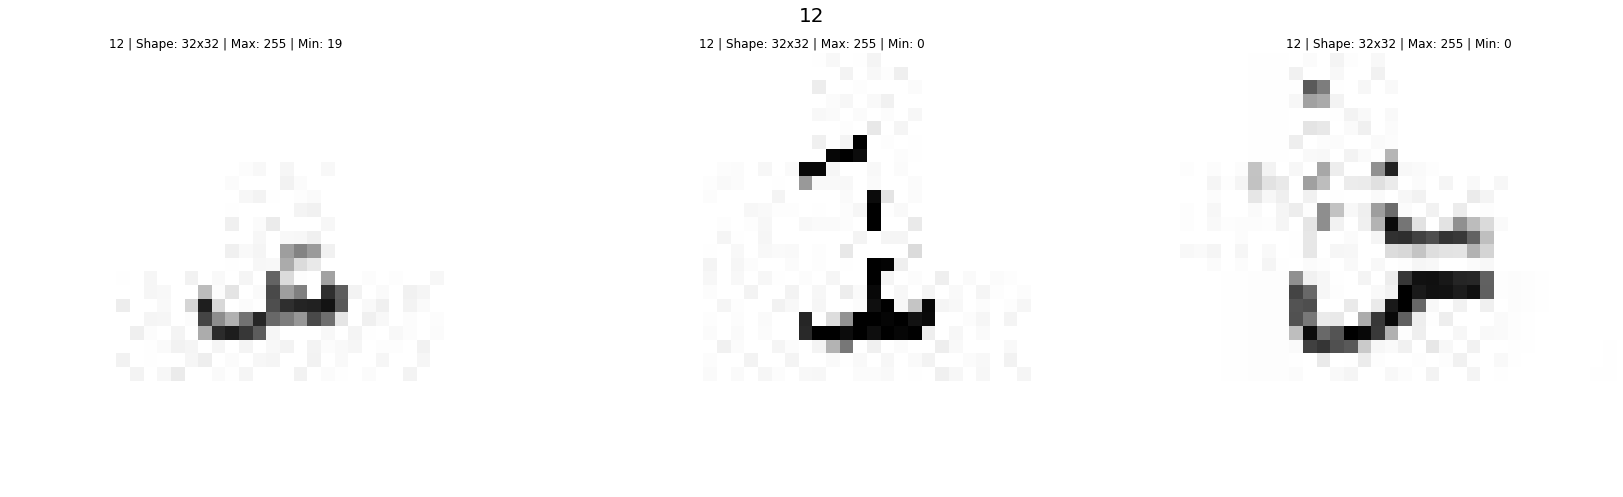

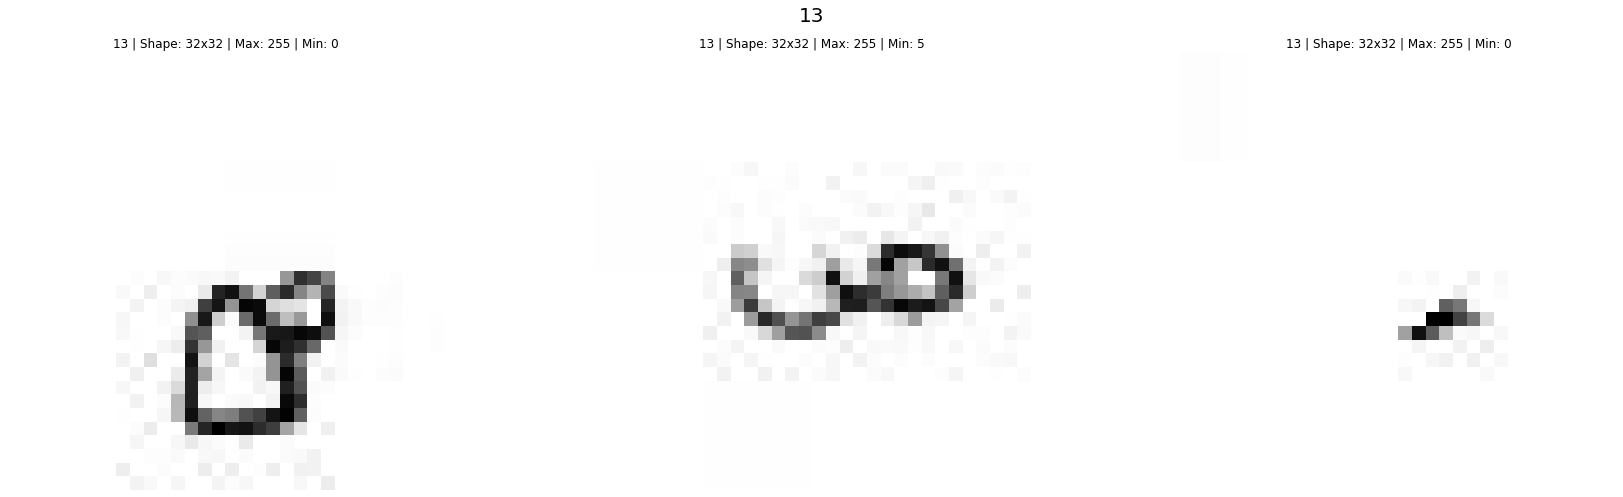

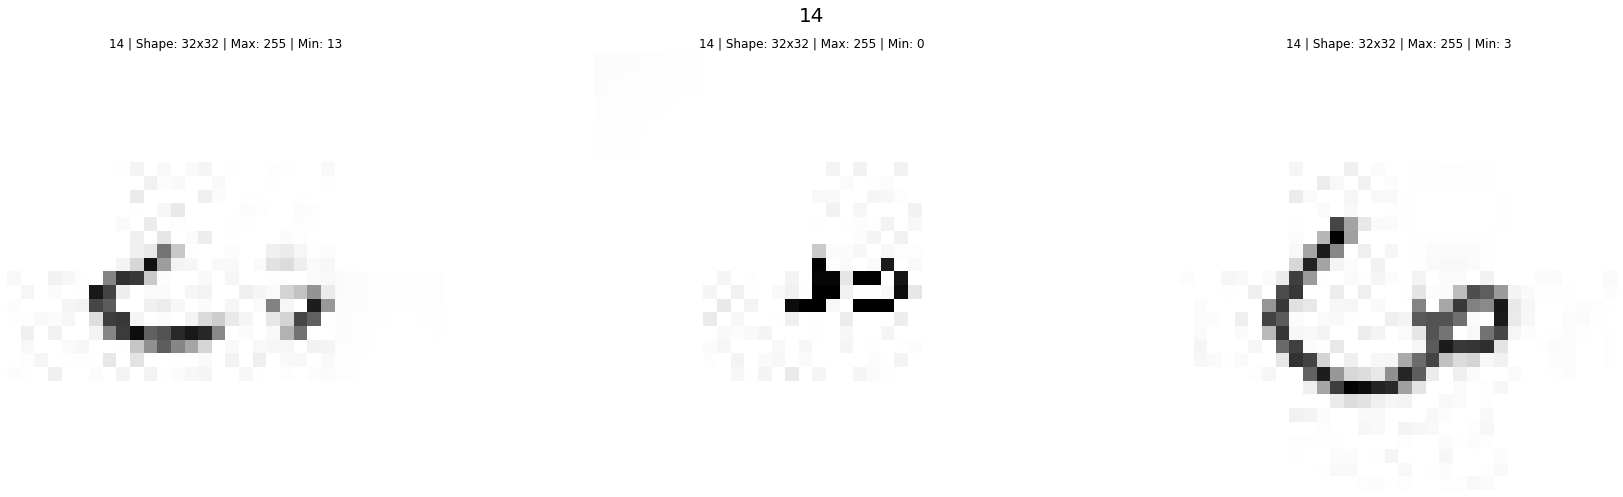

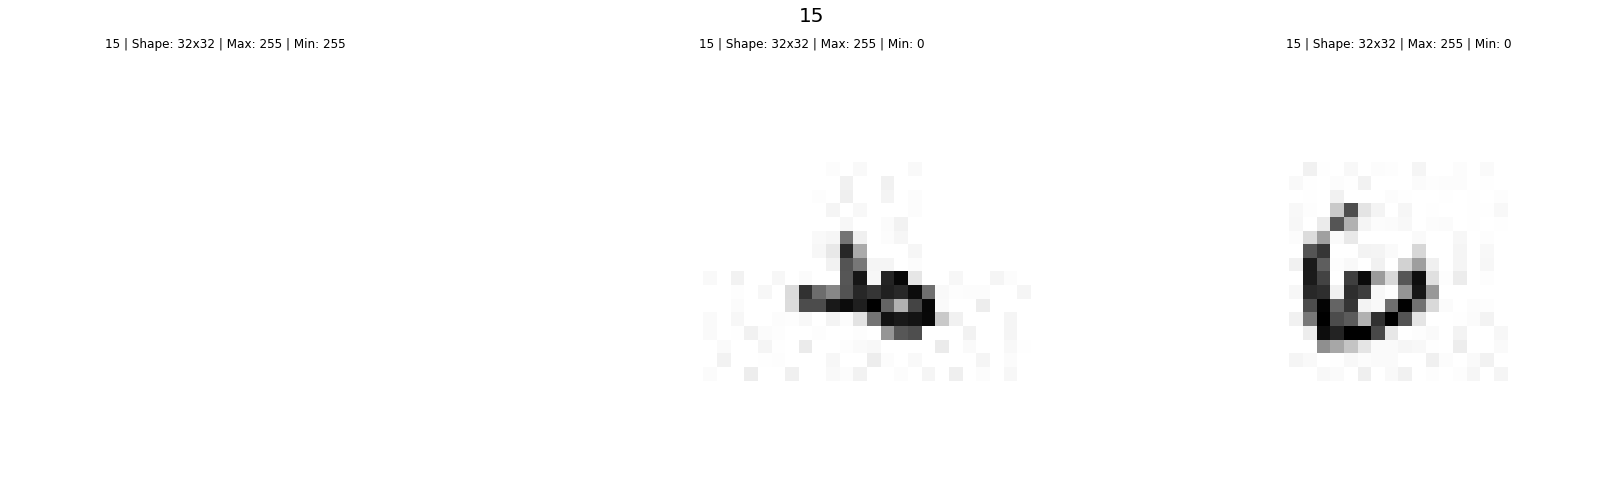

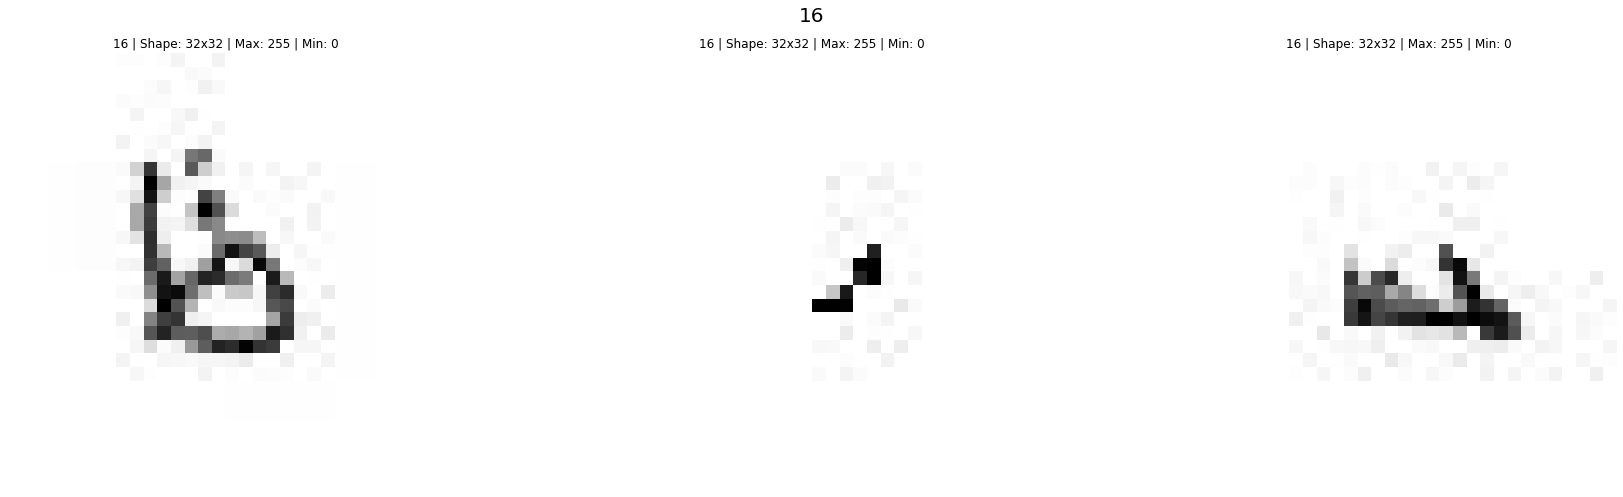

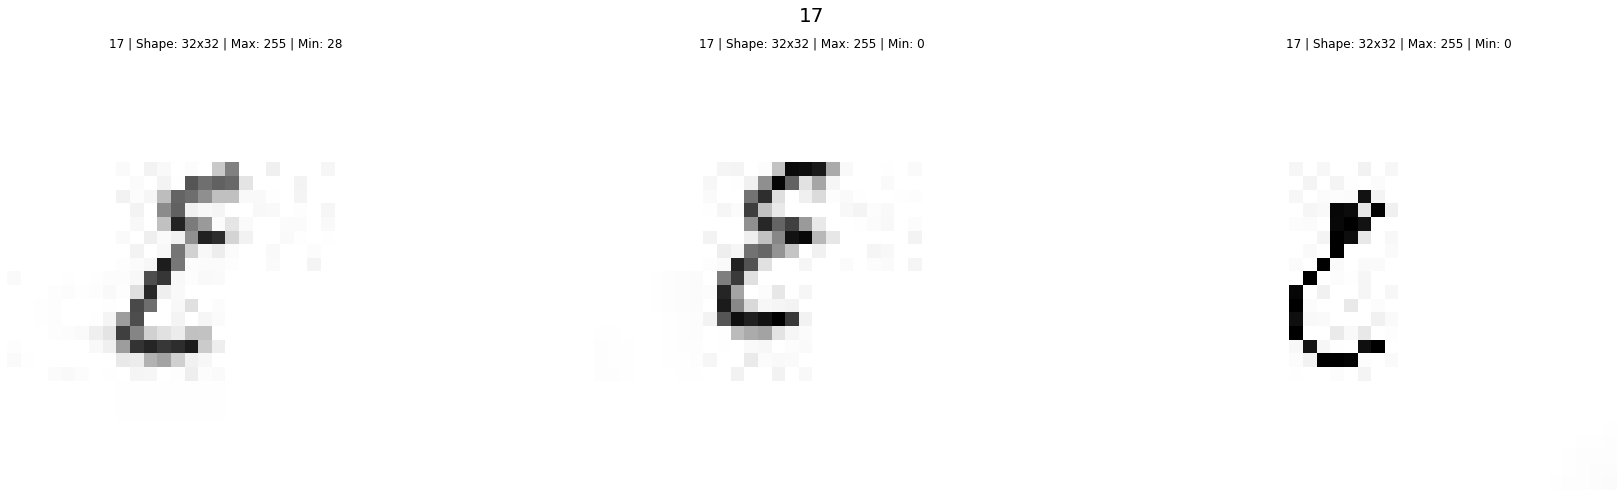

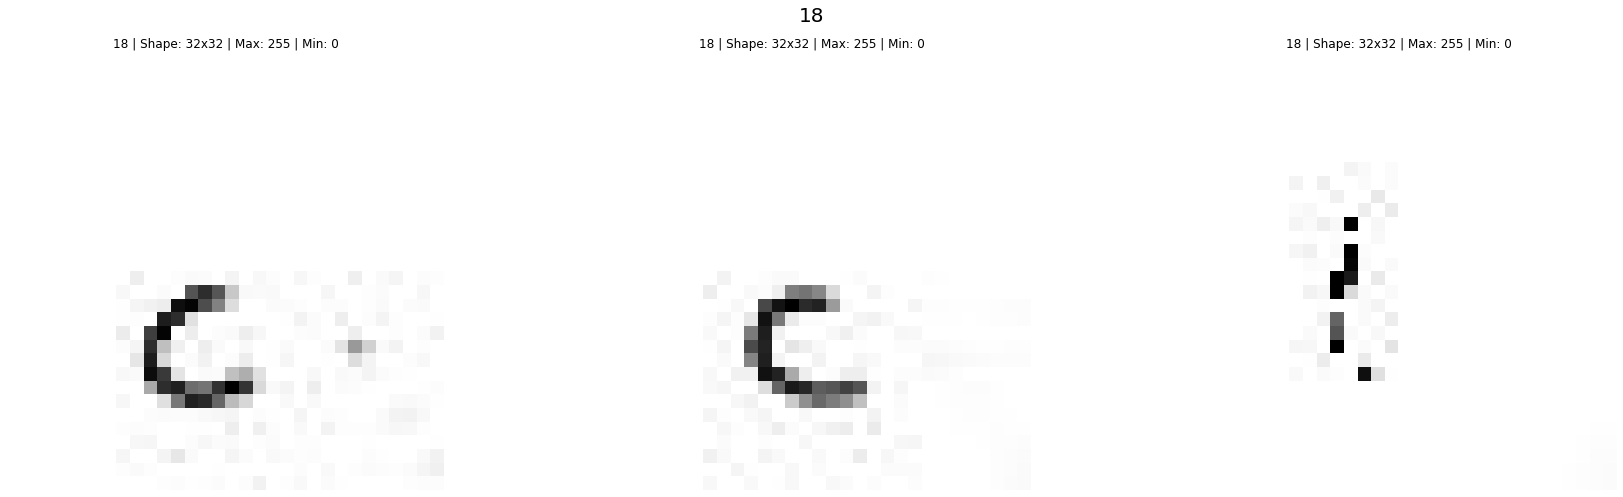

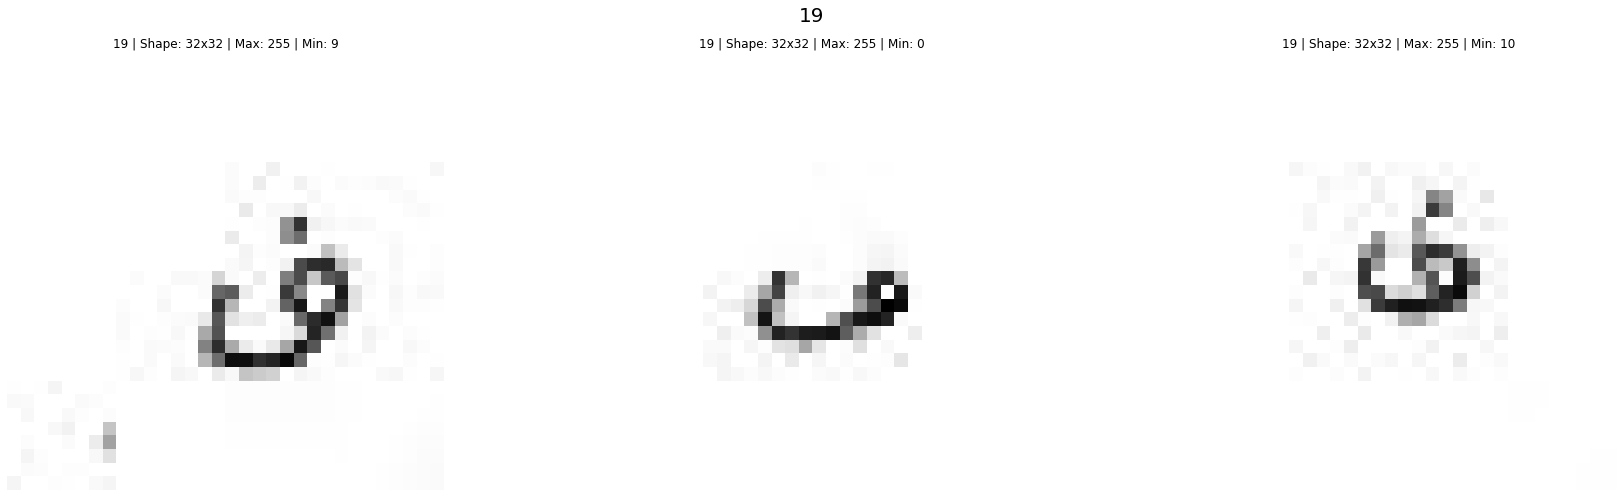

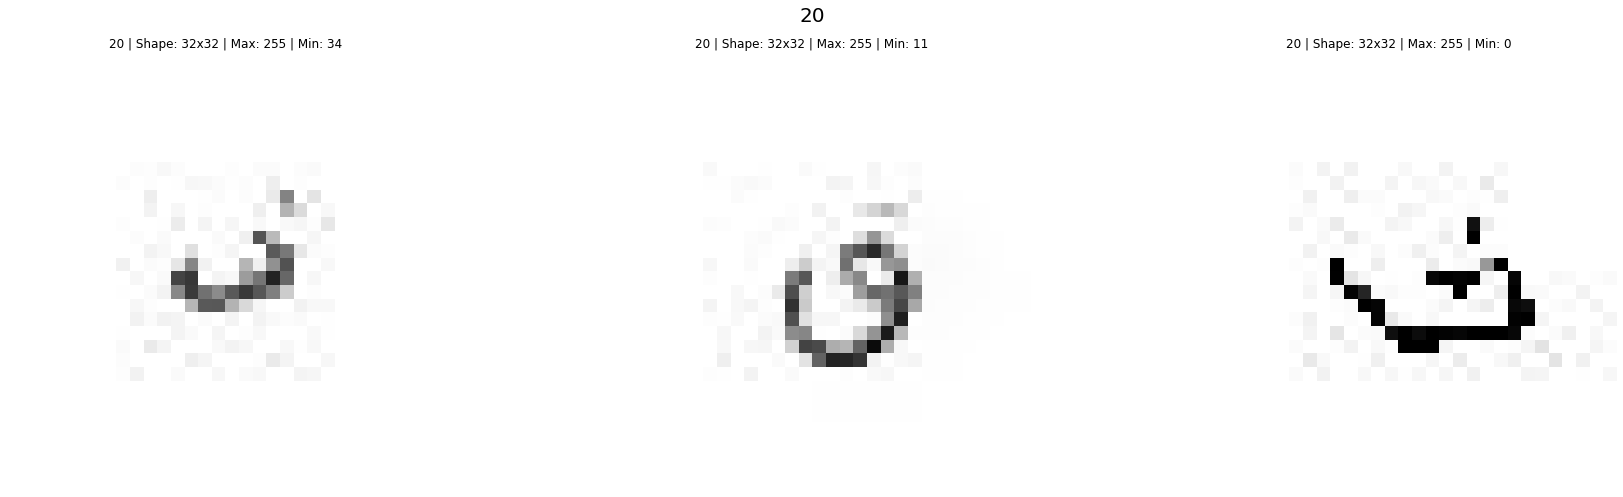

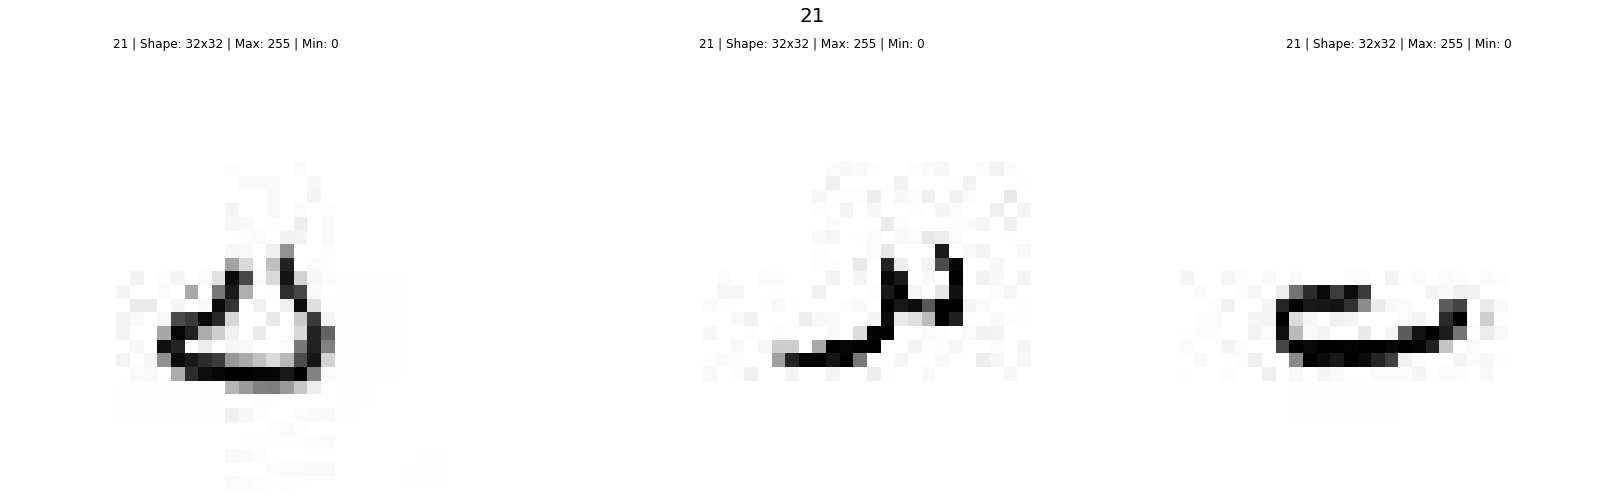

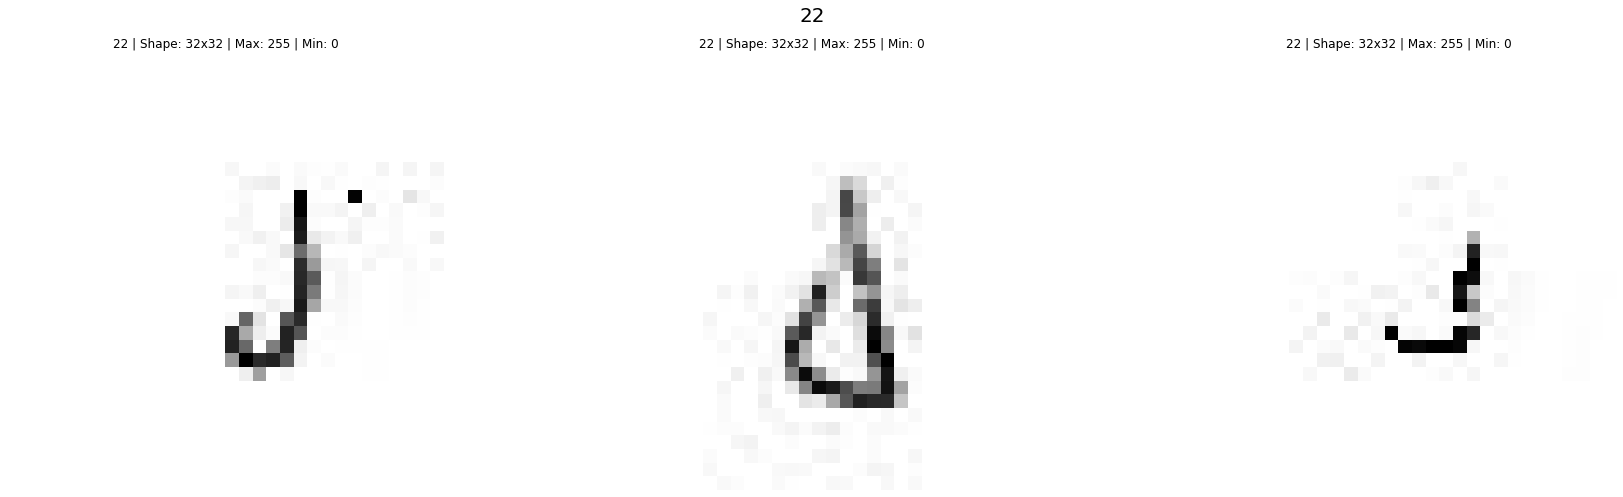

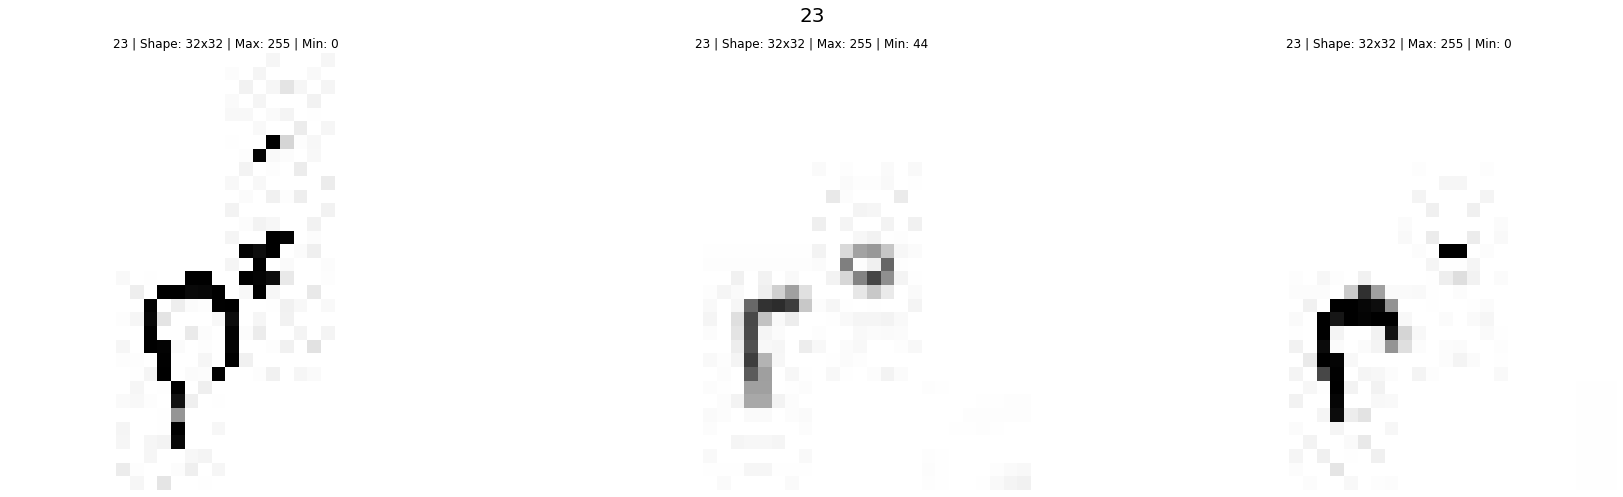

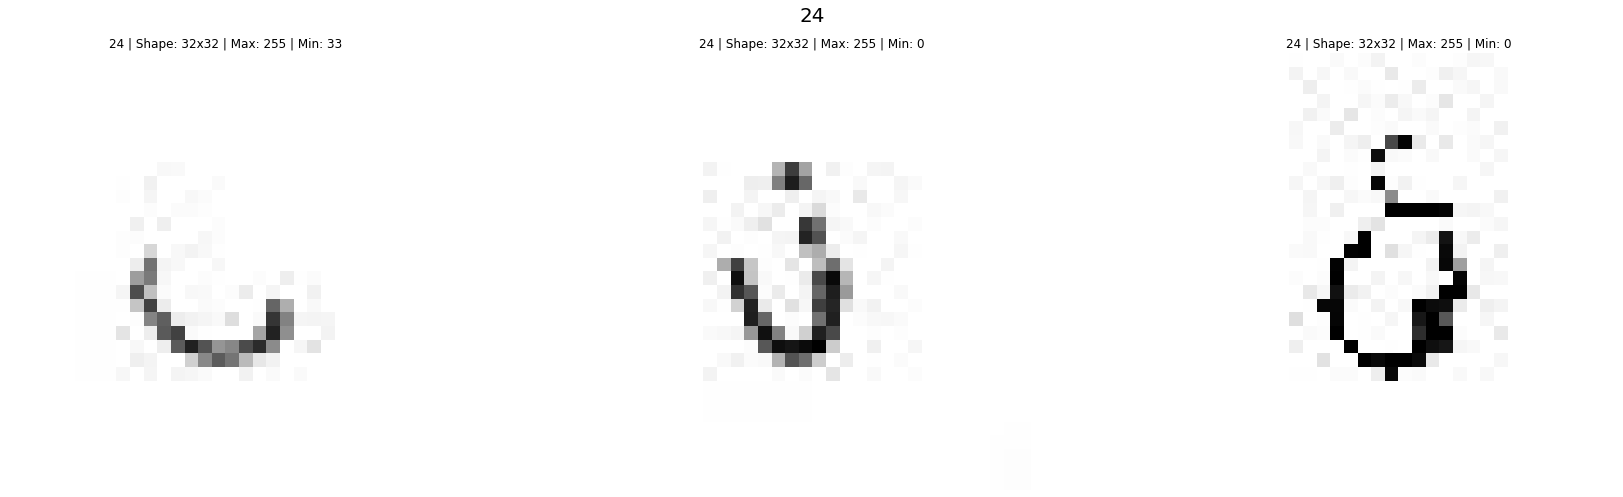

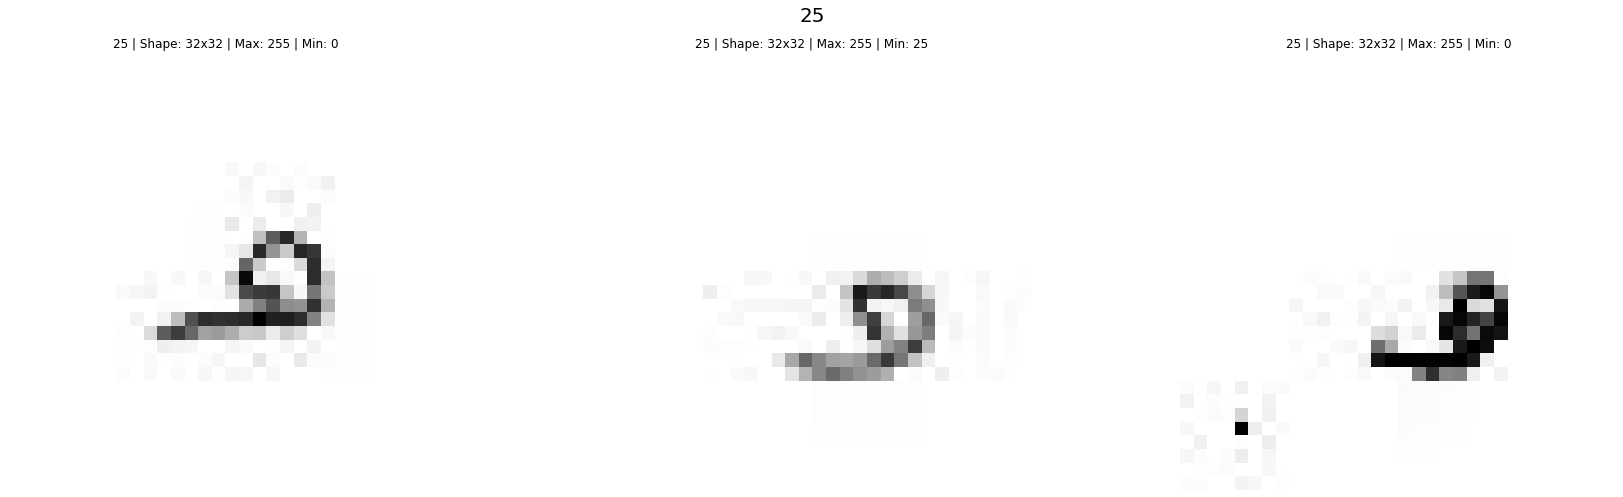

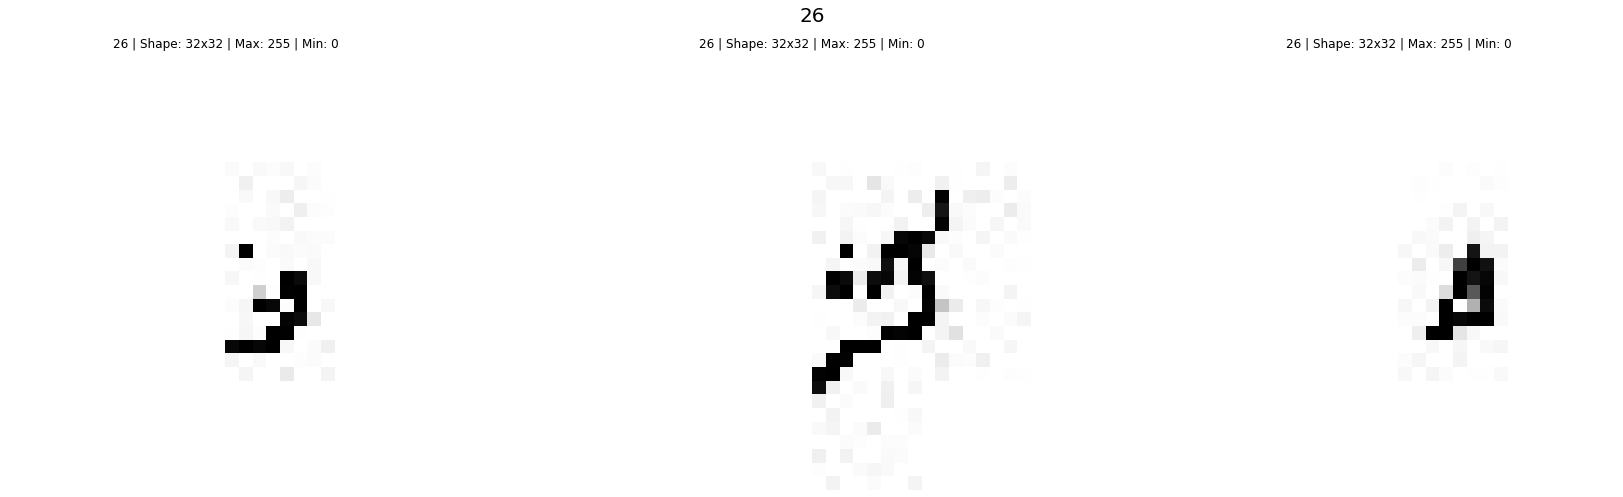

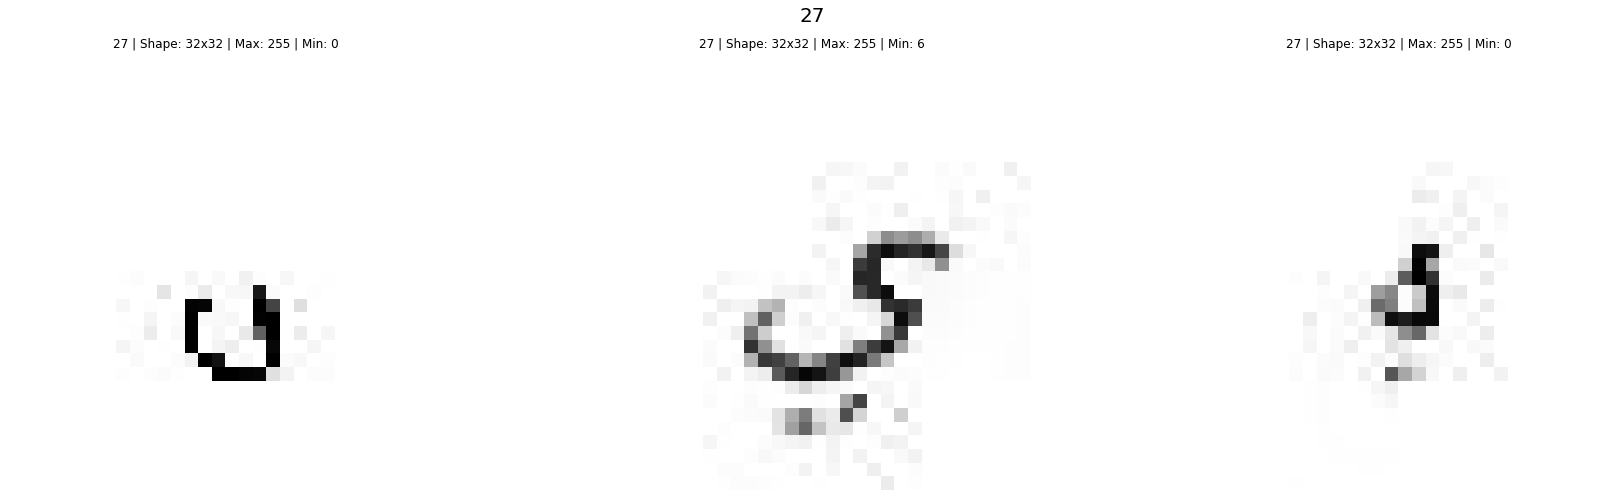

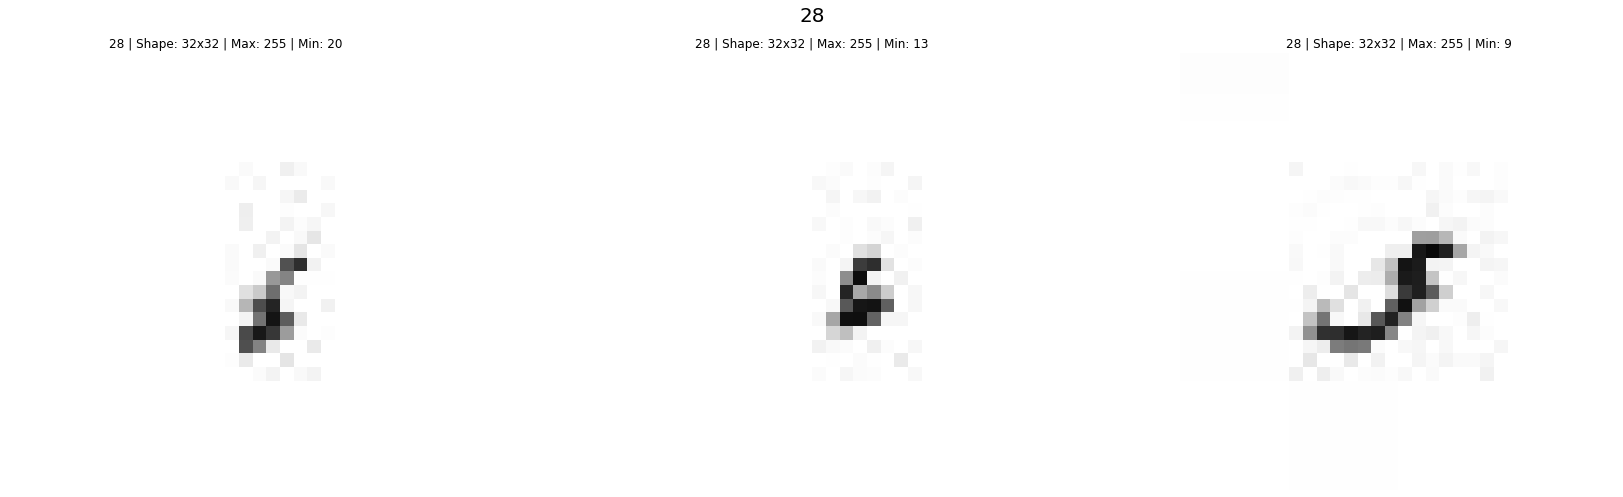

In [11]:

folder_original_data2 = 'Generated/BCE'
files_original_data2 = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
                       '11', '12', '13', '14', '15', '16', '17', '18',
                       '19', '20', '21', '22', '23', '24', '25', '26',
                       '27', '28']

for file in files_original_data2:
    path = os.path.join(folder_original_data2, file)
    fig, axes = plt.subplots(1, 3, figsize=(25, 7))

    for i, img in enumerate(os.listdir(path)[:3]):
        img_array = cv2.imread(os.path.join(path, img))
        img_array_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Get image shape and pixel values
        img_shape = img_array.shape
        max_pixel = np.max(img_array)
        min_pixel = np.min(img_array)

        # Set the title with image shape, max, and min pixel values
        axes[i].imshow(img_array_rgb)
        axes[i].set_title(f"{file} | Shape: {img_shape[0]}x{img_shape[1]} | Max: {max_pixel} | Min: {min_pixel}")
        axes[i].axis('off')

    plt.suptitle(f'{file}', fontsize=20)
    plt.tight_layout()
    plt.show()

In [14]:
data_transforms = transforms.Compose([
    transforms.Resize((32, 32), interpolation=Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize([0.485], [0.229])  # Normalization
])

data_dir2 = 'Generated/BCE'

image_dataset2 = datasets.ImageFolder(data_dir2, transform=data_transforms)

# class_counts_before = {class_name: 0 for class_name in image_dataset.classes}
# for _, label in image_dataset:
#     class_counts_before[image_dataset.classes[label]] += 1

# for class_name, count in class_counts_before.items():
#     print(f"{class_name}: {count}")
# print(f"Total number of images : {len(image_dataset)}\n")

class_indices = {class_name: [] for class_name in image_dataset2.classes}
for idx, (_, label2) in enumerate(image_dataset2):
    class_name = image_dataset2.classes[label2]
    class_indices[class_name].append(idx)

target_count = 500

upsampled_datasets2 = []

for class_name, indices in class_indices.items():
    current_count = len(indices)
    if current_count < target_count:
        # Number of extra images needed
        additional_count = target_count - current_count

        #Randomly sample with replacement from current indices
        additional_indices = np.random.choice(indices, additional_count, replace=True)

        # Combine original and additional indices
        combined_indices = indices + additional_indices.tolist()

        # Create Subset for the upsampled class
        upsampled_dataset2 = Subset(image_dataset2, combined_indices)
    else:
        # Use existing data if it already meets or exceeds target count
        upsampled_dataset2 = Subset(image_dataset2, indices)

    upsampled_datasets2.append(upsampled_dataset2)

final_dataset2 = image_dataset2

dataloader2 = DataLoader(final_dataset2, batch_size=32, shuffle=True)

# print("Class distribution after BALANCNG:")
# new_class_counts = {class_name: 0 for class_name in image_dataset2.classes}
# for _, labels in dataloader2:
#     for label2 in labels:
#          new_class_counts[image_dataset2.classes[label2.item()]] += 1

# for class_name, count in new_class_counts.items():
#      print(f"{class_name}: {count}")
# print(f"Total number of images after BALANCNG: {len(final_dataset2)}")


C:\Users\MUHAMM~1\AppData\Local\Temp/ipykernel_17392/1017585613.py:2: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  transforms.Resize((32, 32), interpolation=Image.BICUBIC),


In [15]:
len(final_dataset2)

58232

In [16]:
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.model_selection import train_test_split

# Get labels for both datasets (assuming the labels are stored in the same way)
final_labels1 = [label for _, label in final_dataset1]

# Split training data (from final_dataset1)
train_indices, _ = train_test_split(
    np.arange(len(final_dataset1)),
    test_size=0.15,
    stratify=final_labels1,
    random_state=42
)
 #Create dataset subsets
train_subset = Subset(final_dataset1, train_indices)

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)


# Print dataset sizes
print(f"Training set size: {len(final_dataset1)}")

Training set size: 12780


In [17]:
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.model_selection import train_test_split

# Get labels for final_dataset2
# final_labels2 = [label for _, label in final_dataset2]  # This line is no longer needed
# instead use labels from final_dataset1, this dataset represents the overall image labels in your dataset:
final_labels2 = [label2 for _, label2 in final_dataset2]

# Split validation and test data from final_dataset2
val_indices, test_indices = train_test_split(
    np.arange(len(final_dataset2)),
    test_size=0.5,
    stratify=final_labels2,  # Use labels from final_dataset1 for stratification
    random_state=42
)

# Create dataset subsets
val_subset = Subset(final_dataset2, val_indices)
test_subset = Subset(final_dataset2, test_indices)

# Create DataLoaders
val_loader = DataLoader(val_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

# Print dataset sizes
print(f"Validation set size: {len(val_subset)}")
print(f"Testing set size: {len(test_subset)}")

Validation set size: 29116
Testing set size: 29116


In [43]:
# class ComplexCNN(nn.Module):
#     def __init__(self, num_classes=29):
#         super(ComplexCNN, self).__init__()
#         self.features = nn.Sequential(
#             # Convolution Block 1
#             nn.Conv2d(3, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(128, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.MaxPool2d(2, 2),
#             nn.Dropout(0.25),

#             # Convolution Block 2
#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(256, 256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.MaxPool2d(2, 2),
#             nn.Dropout(0.25),

#             # Convolution Block 3
#             nn.Conv2d(256, 512, kernel_size=3, padding=1),
#             nn.BatchNorm2d(512),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(512, 512, kernel_size=3, padding=1),
#             nn.BatchNorm2d(512),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.MaxPool2d(2, 2),
#             nn.Dropout(0.25),

#             # Convolution Block 4
#             nn.Conv2d(512, 1024, kernel_size=3, padding=1),
#             nn.BatchNorm2d(1024),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
#             nn.BatchNorm2d(1024),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.AdaptiveAvgPool2d((4, 4)),
#             nn.Dropout(0.25),
#         )

#         self.classifier = nn.Sequential(
#             nn.Linear(1024 * 4 * 4, 4096),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Dropout(0.5),
#             nn.Linear(4096, 1024),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Dropout(0.5),
#             nn.Linear(1024, 256),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Dropout(0.5),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = x.view(x.size(0), -1)
#         x = self.classifier(x)
#         return x


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class AttentionBlock(nn.Module):
    def __init__(self, channel, ratio=8):
        super(AttentionBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channel, channel // ratio)
        self.fc2 = nn.Linear(channel // ratio, channel)

    def forward(self, x):
        squeeze = self.global_avg_pool(x).view(x.size(0), -1)
        excitation = F.relu(self.fc1(squeeze))
        excitation = torch.sigmoid(self.fc2(excitation)).view(x.size(0), x.size(1), 1, 1)
        return x * excitation

class SiameseModel(nn.Module):
    def __init__(self, classes):
        super(SiameseModel, self).__init__()
        
        self.densenet = models.densenet169(pretrained=True).features
        self.mobilenet = models.mobilenet_v2(pretrained=True).features
        self.regnet = nn.Sequential(*list(models.regnet_y_3_2gf(pretrained=True).children())[:-1])
        
        # Freeze partial layers
        self._freeze_layers(self.regnet, portion=1/16)
        self._freeze_layers(self.densenet, portion=1/3)
        self._freeze_layers(self.mobilenet, portion=1/3)
        
        self.att_densenet = AttentionBlock(1664)  # Output channels from DenseNet169
        self.att_regnet = AttentionBlock(1512)   # Output channels from RegNetY_3_2GF
        self.att_mobilenet = AttentionBlock(1280) # Output channels from MobileNetV2
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Sequential(
            nn.BatchNorm1d(1664 + 1512 + 1280),
            nn.Linear(1664 + 1512 + 1280, 8192),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(8192, 8196),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(8196, classes)
        )

    def _freeze_layers(self, model, portion):
        num_layers = len(list(model.parameters()))
        freeze_count = int(num_layers * portion)
        for i, param in enumerate(model.parameters()):
            if i < freeze_count:
                param.requires_grad = False
    
    def forward(self, x):
        x1 = self.densenet(x)
        x1 = self.att_densenet(x1)
        x1 = self.global_pool(x1).view(x1.size(0), -1)

        x2 = self.regnet(x)
        x2 = self.att_regnet(x2)
        x2 = self.global_pool(x2).view(x2.size(0), -1)
        
        x3 = self.mobilenet(x)
        x3 = self.att_mobilenet(x3)
        x3 = self.global_pool(x3).view(x3.size(0), -1)
        
        concatenated = torch.cat([x1, x2, x3], dim=1)
        out = self.fc(concatenated)
        return out

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [55]:
num_classes = 29
model = SiameseModel(classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.01, patience=7,
                                                 verbose=True)

In [56]:
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, delta=0):

        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model = None

    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model = copy.deepcopy(model.state_dict())
            if self.verbose:
                print(f"Initial validation loss: {val_loss:.4f}. Saving model.")
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"Validation loss did not improve. EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
            if self.verbose:
                print(f"Validation loss improved to: {val_loss:.4f}. Saving model.")


In [57]:
# def train_model(model, criterion, optimizer, scheduler,
#                 train_loader, val_loader, device, num_epochs=50,
#                 patience=10):
#     since = time.time()

#     early_stopping = EarlyStopping(patience=patience, verbose=True)

#     best_model_wts = copy.deepcopy(model.state_dict())
#     best_loss = float('inf')

#     for epoch in range(num_epochs):
#         print(f"Epoch {epoch+1}/{num_epochs}")
#         print("-" * 10)

#         # Each epoch has a training and validation phase
#         for phase in ['train', 'val']:
#             if phase == 'train':
#                 model.train()  # Set model to training mode
#                 dataloader = train_loader
#             else:
#                 model.eval()   # Set model to evaluate mode
#                 dataloader = val_loader

#             running_loss = 0.0
#             running_corrects = 0

#             # Iterate over data
#             for inputs, labels in dataloader:
#                 inputs = inputs.to(device)
#                 labels = labels.to(device)

#                 # Zero the parameter gradients
#                 optimizer.zero_grad()

#                 # Forward
#                 # Track history only if in train
#                 with torch.set_grad_enabled(phase == 'train'):
#                     outputs = model(inputs)
#                     loss = criterion(outputs, labels)
#                     _, preds = torch.max(outputs, 1)

#                     # Backward + optimize only if in training phase
#                     if phase == 'train':
#                         loss.backward()
#                         optimizer.step()

#                 # Statistics
#                 running_loss += loss.item() * inputs.size(0)
#                 running_corrects += torch.sum(preds == labels.data)

#             epoch_loss = running_loss / len(dataloader.dataset)
#             epoch_acc = running_corrects.double() / len(dataloader.dataset)

#             print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

#             # Deep copy the model
#             if phase == 'val':
#                 scheduler.step(epoch_loss)
#                 early_stopping(epoch_loss, model)
#                 if epoch_loss < best_loss:
#                     best_loss = epoch_loss
#                     best_model_wts = copy.deepcopy(model.state_dict())
#                 if early_stopping.early_stop:
#                     print("Early stopping triggered.")
#                     model.load_state_dict(early_stopping.best_model)
#                     time_elapsed = time.time() - since
#                     print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
#                     print(f"Best Validation Loss: {best_loss:.4f}")
#                     return model

#         print()

#     time_elapsed = time.time() - since
#     print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
#     print(f"Best Validation Loss: {best_loss:.4f}")

#     # Load best model weights
#     model.load_state_dict(best_model_wts)
#     return model


In [58]:
import time
import copy
import matplotlib.pyplot as plt  # Import matplotlib for visualization

def train_model(model, criterion, optimizer, scheduler,
                train_loader, val_loader, device, num_epochs=50,
                patience=10):
    since = time.time()

    early_stopping = EarlyStopping(patience=patience, verbose=True)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    train_losses = []  # List to store training losses
    val_losses = []    # List to store validation losses

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloader):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Store the losses
            if phase == 'train':
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)
                scheduler.step(epoch_loss)
                early_stopping(epoch_loss, model)
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                if early_stopping.early_stop:
                    print("Early stopping triggered.")
                    model.load_state_dict(early_stopping.best_model)
                    time_elapsed = time.time() - since
                    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
                    print(f"Best Validation Loss: {best_loss:.4f}")
                    return model, train_losses, val_losses

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Loss: {best_loss:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses  # Return losses

Epoch 1/650
----------


  0%|          | 0/170 [00:00<?, ?it/s]

Train Loss: 1.9952 Acc: 0.4074


  0%|          | 0/910 [00:00<?, ?it/s]

Val Loss: 2.5382 Acc: 0.3588
Initial validation loss: 2.5382. Saving model.

Epoch 2/650
----------


...

Val Loss: 4.3293 Acc: 0.4413
Validation loss did not improve. EarlyStopping counter: 19/20

Epoch 22/650
----------


  0%|          | 0/170 [00:00<?, ?it/s]

Train Loss: 0.0388 Acc: 0.9870


  0%|          | 0/910 [00:00<?, ?it/s]

Val Loss: 4.2799 Acc: 0.4476
Validation loss did not improve. EarlyStopping counter: 20/20
Early stopping triggered.
Training complete in 81m 53s
Best Validation Loss: 2.4940


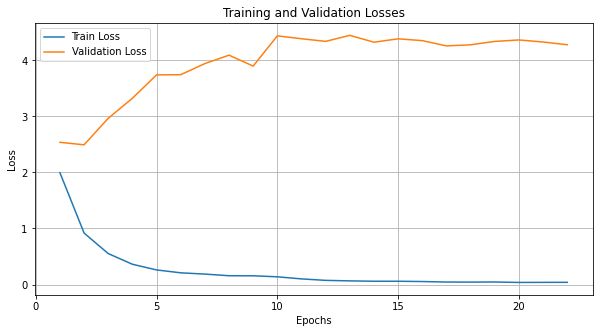

In [59]:
import matplotlib.pyplot as plt

# Set number of epochs
num_epochs = 650
patience = 20

# Train the model and get the losses
trained_model, train_losses, val_losses = train_model(model, criterion, optimizer, scheduler,
                                                      train_loader, val_loader, device,
                                                      num_epochs=num_epochs, patience=patience)

# Plot the losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total

    print(f"Test Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    return epoch_loss, epoch_acc

In [ ]:
evaluate_model(trained_model, test_loader, device)

torch.save(trained_model.state_dict(), "HIJJA_Original&Generated_CLASSIFICATION_CNN_MODEL+V.pth")